<a href="https://colab.research.google.com/github/Beelzebub0956/Cognitive-Reasoning-Visual-Interrogation/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=============================================================================
MODULE 1: IMAGE ACQUISITION AND PREPROCESSING
=============================================================================

This module handles:
- Loading images from the train_images directory using image_id
- Resizing images to a fixed size (224 x 224) suitable for CNN input
- Normalizing pixel values to range [0, 1]
- Converting images to NumPy arrays

============================================================================

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install Pillow numpy

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
from PIL import Image
from typing import Optional, List, Tuple, Union

BASE_PATH = "/content/drive/MyDrive/VQA_capstone_1"

TARGET_SIZE = (224, 224)
NUM_CHANNELS = 3
DEFAULT_IMAGE_DIR = os.path.join(BASE_PATH, "train_images")
IMAGE_EXTENSION = ".png"
IMAGE_PREFIX = "abstract_v002_train2015_"


def construct_image_filename(image_id: int) -> str:
    padded_id = str(image_id).zfill(12)
    filename = f"{IMAGE_PREFIX}{padded_id}{IMAGE_EXTENSION}"
    return filename


def construct_image_path(image_id: int, image_dir: str = DEFAULT_IMAGE_DIR) -> str:
    filename = construct_image_filename(image_id)
    return os.path.join(image_dir, filename)


def load_and_preprocess_image(
    image_id: int,
    image_dir: str = DEFAULT_IMAGE_DIR,
    target_size: Tuple[int, int] = TARGET_SIZE,
    normalize: bool = True
) -> Optional[np.ndarray]:
    image_path = construct_image_path(image_id, image_dir)

    if not os.path.exists(image_path):
        print(f"Error: Image file not found: {image_path}")
        print(f"Image ID: {image_id}")
        return None

    try:
        image = Image.open(image_path)

        if image.mode != 'RGB':
            image = image.convert('RGB')

        image = image.resize(target_size, Image.LANCZOS)
        image_array = np.array(image, dtype=np.float32)

        if normalize:
            image_array = image_array / 255.0

        return image_array

    except Exception as e:
        print(f"Error loading image {image_id}: {str(e)}")
        return None


def load_multiple_images(
    image_ids: List[int],
    image_dir: str = DEFAULT_IMAGE_DIR,
    target_size: Tuple[int, int] = TARGET_SIZE,
    normalize: bool = True,
    verbose: bool = True
) -> Tuple[np.ndarray, List[int]]:
    images = []
    valid_ids = []
    failed_count = 0

    if verbose:
        print(f"Loading {len(image_ids)} images from '{image_dir}'...")

    for i, image_id in enumerate(image_ids):
        img = load_and_preprocess_image(
            image_id=image_id,
            image_dir=image_dir,
            target_size=target_size,
            normalize=normalize
        )

        if img is not None:
            images.append(img)
            valid_ids.append(image_id)
        else:
            failed_count += 1

        if verbose and (i + 1) % 100 == 0:
            print(f"  Processed {i + 1}/{len(image_ids)} images...")

    if verbose:
        print(f"Successfully loaded: {len(images)} images")
        if failed_count > 0:
            print(f"Failed to load: {failed_count} images")

    if images:
        images_array = np.array(images, dtype=np.float32)
    else:
        images_array = np.empty((0, target_size[0], target_size[1], NUM_CHANNELS),
                                  dtype=np.float32)

    return images_array, valid_ids


def get_available_image_ids(image_dir: str = DEFAULT_IMAGE_DIR) -> List[int]:
    image_ids = []

    if not os.path.exists(image_dir):
        print(f"Error: Image directory not found: {image_dir}")
        return []

    for filename in os.listdir(image_dir):
        if filename.startswith(IMAGE_PREFIX) and filename.endswith(IMAGE_EXTENSION):
            try:
                id_str = filename.replace(IMAGE_PREFIX, "").replace(IMAGE_EXTENSION, "")
                image_id = int(id_str)
                image_ids.append(image_id)
            except ValueError:
                continue

    return sorted(image_ids)


class ImagePreprocessor:
    def __init__(
        self,
        image_dir: str = DEFAULT_IMAGE_DIR,
        target_size: Tuple[int, int] = TARGET_SIZE,
        normalize: bool = True
    ):
        self.image_dir = image_dir
        self.target_size = target_size
        self.normalize = normalize

        if not os.path.exists(image_dir):
            print(f"Warning: Image directory '{image_dir}' does not exist!")

    def get_image(self, image_id: int) -> Optional[np.ndarray]:
        return load_and_preprocess_image(
            image_id=image_id,
            image_dir=self.image_dir,
            target_size=self.target_size,
            normalize=self.normalize
        )

    def get_batch(self, image_ids: List[int], verbose: bool = False) -> Tuple[np.ndarray, List[int]]:
        return load_multiple_images(
            image_ids=image_ids,
            image_dir=self.image_dir,
            target_size=self.target_size,
            normalize=self.normalize,
            verbose=verbose
        )

    def get_available_ids(self) -> List[int]:
        return get_available_image_ids(self.image_dir)

    def __repr__(self) -> str:
        return (f"ImagePreprocessor(image_dir='{self.image_dir}', "
                f"target_size={self.target_size}, normalize={self.normalize})")


print("=" * 70)
print("MODULE 1: IMAGE ACQUISITION AND PREPROCESSING - DEMO")
print("=" * 70)

IMAGE_DIR = os.path.join(BASE_PATH, "train_images")

print("\n--- Example 1: Load Single Image (Functional Approach) ---")

available_ids = get_available_image_ids(IMAGE_DIR)
print(f"Total images available: {len(available_ids)}")

if available_ids:
    test_id = available_ids[0]
    print(f"\nLoading image with ID: {test_id}")

    img = load_and_preprocess_image(test_id, IMAGE_DIR)

    if img is not None:
        print(f"  Image shape: {img.shape}")
        print(f"  Data type: {img.dtype}")
        print(f"  Pixel value range: [{img.min():.4f}, {img.max():.4f}]")
        print(f"  Mean pixel value: {img.mean():.4f}")

print("\n--- Example 2: Load Multiple Images ---")

if len(available_ids) >= 5:
    sample_ids = available_ids[:5]
    print(f"Loading images with IDs: {sample_ids}")

    images, valid_ids = load_multiple_images(sample_ids, IMAGE_DIR, verbose=True)

    print(f"\nBatch shape: {images.shape}")
    print(f"Successfully loaded IDs: {valid_ids}")

print("\n--- Example 3: Class-Based Approach ---")

preprocessor = ImagePreprocessor(image_dir=IMAGE_DIR)
print(f"Created: {preprocessor}")

if available_ids:
    img = preprocessor.get_image(available_ids[0])
    if img is not None:
        print(f"Single image shape: {img.shape}")

    if len(available_ids) >= 3:
        batch, ids = preprocessor.get_batch(available_ids[:3], verbose=True)
        print(f"Batch shape: {batch.shape}")

print("\n--- Example 4: Error Handling Test ---")

invalid_id = 999999999
print(f"Attempting to load invalid image ID: {invalid_id}")
result = load_and_preprocess_image(invalid_id, IMAGE_DIR)
print(f"Result: {result}")

print("\n" + "=" * 70)
print("Image Preprocessing Module Demo Complete!")
print("=" * 70)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODULE 1: IMAGE ACQUISITION AND PREPROCESSING - DEMO

--- Example 1: Load Single Image (Functional Approach) ---
Total images available: 20000

Loading image with ID: 0
  Image shape: (224, 224, 3)
  Data type: float32
  Pixel value range: [0.0000, 1.0000]
  Mean pixel value: 0.4912

--- Example 2: Load Multiple Images ---
Loading images with IDs: [0, 1, 2, 3, 4]
Loading 5 images from '/content/drive/MyDrive/VQA_capstone_1/train_images'...
Successfully loaded: 5 images

Batch shape: (5, 224, 224, 3)
Successfully loaded IDs: [0, 1, 2, 3, 4]

--- Example 3: Class-Based Approach ---
Created: ImagePreprocessor(image_dir='/content/drive/MyDrive/VQA_capstone_1/train_images', target_size=(224, 224), normalize=True)
Single image shape: (224, 224, 3)
Loading 3 images from '/content/drive/MyDrive/VQA_capstone_1/train_images'...
Successfully loaded: 3 images
Batch shape

MODULE 2: QUESTION PROCESSING
=============================================================================
This module handles:
- Loading questions from JSON files
- Extracting question text
- Tokenization using TensorFlow/Keras Tokenizer
- Converting words to numerical sequences
- Padding sequences to fixed length


In [ ]:
!pip install tensorflow numpy

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import re
import numpy as np
from typing import Optional, List, Tuple, Dict, Union

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

BASE_PATH = "/content/drive/MyDrive/VQA_capstone_1"

MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 20
PAD_TOKEN = "<PAD>"
OOV_TOKEN = "<OOV>"
DEFAULT_QUESTIONS_FILE = os.path.join(BASE_PATH, "train_questions/OpenEnded_abstract_v002_train2015_questions.json")


def clean_question(question: str) -> str:
    question = question.lower()
    question = re.sub(r'[^a-z0-9\s]', '', question)
    question = re.sub(r'\s+', ' ', question)
    question = question.strip()
    return question


def load_questions_from_json(json_path: str) -> List[Dict]:
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Questions file not found: {json_path}")

    print(f"Loading questions from: {json_path}")

    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    questions = data.get('questions', [])
    print(f"Loaded {len(questions)} questions")

    return questions


def extract_question_texts(
    questions_data: List[Dict],
    clean: bool = True
) -> Tuple[List[str], List[int], List[int]]:
    question_texts = []
    image_ids = []
    question_ids = []

    for q in questions_data:
        text = q.get('question', '')

        if clean:
            text = clean_question(text)

        question_texts.append(text)
        image_ids.append(q.get('image_id', -1))
        question_ids.append(q.get('question_id', -1))

    return question_texts, image_ids, question_ids


def create_tokenizer(
    texts: List[str],
    max_vocab_size: int = MAX_VOCAB_SIZE,
    oov_token: str = OOV_TOKEN
) -> Tokenizer:
    tokenizer = Tokenizer(
        num_words=max_vocab_size,
        oov_token=oov_token,
        filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
        lower=True,
        split=' '
    )

    print(f"Fitting tokenizer on {len(texts)} texts...")
    tokenizer.fit_on_texts(texts)

    vocab_size = len(tokenizer.word_index) + 1
    print(f"Vocabulary size: {vocab_size} unique words")
    print(f"Using top {min(max_vocab_size, vocab_size)} words")

    return tokenizer


def texts_to_sequences(
    tokenizer: Tokenizer,
    texts: List[str]
) -> List[List[int]]:
    return tokenizer.texts_to_sequences(texts)


def pad_question_sequences(
    sequences: List[List[int]],
    max_length: int = MAX_SEQUENCE_LENGTH,
    padding: str = 'post',
    truncating: str = 'post'
) -> np.ndarray:
    padded = pad_sequences(
        sequences,
        maxlen=max_length,
        padding=padding,
        truncating=truncating,
        value=0
    )
    return padded


def get_vocabulary(tokenizer: Tokenizer) -> Dict[str, int]:
    return tokenizer.word_index


def get_reverse_vocabulary(tokenizer: Tokenizer) -> Dict[int, str]:
    return {v: k for k, v in tokenizer.word_index.items()}


def process_question(
    question: str,
    tokenizer: Tokenizer,
    max_length: int = MAX_SEQUENCE_LENGTH,
    clean: bool = True
) -> np.ndarray:
    if clean:
        question = clean_question(question)

    sequence = tokenizer.texts_to_sequences([question])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post',
        value=0
    )

    return padded


def decode_sequence(
    sequence: np.ndarray,
    tokenizer: Tokenizer
) -> str:
    reverse_vocab = get_reverse_vocabulary(tokenizer)

    if isinstance(sequence, np.ndarray):
        sequence = sequence.flatten().tolist()

    words = []
    for idx in sequence:
        if idx > 0 and idx in reverse_vocab:
            words.append(reverse_vocab[idx])

    return ' '.join(words)


class QuestionPreprocessor:
    def __init__(
        self,
        max_vocab_size: int = MAX_VOCAB_SIZE,
        max_sequence_length: int = MAX_SEQUENCE_LENGTH,
        oov_token: str = OOV_TOKEN
    ):
        self.max_vocab_size = max_vocab_size
        self.max_sequence_length = max_sequence_length
        self.oov_token = oov_token
        self.tokenizer = None
        self.vocabulary = None
        self.is_fitted = False
        self.question_texts = None
        self.image_ids = None
        self.question_ids = None

    def fit_from_json(
        self,
        json_path: str,
        clean: bool = True
    ) -> 'QuestionPreprocessor':
        questions_data = load_questions_from_json(json_path)

        self.question_texts, self.image_ids, self.question_ids = \
            extract_question_texts(questions_data, clean=clean)

        self.tokenizer = create_tokenizer(
            self.question_texts,
            max_vocab_size=self.max_vocab_size,
            oov_token=self.oov_token
        )

        self.vocabulary = get_vocabulary(self.tokenizer)
        self.is_fitted = True

        return self

    def fit(
        self,
        texts: List[str]
    ) -> 'QuestionPreprocessor':
        self.question_texts = [clean_question(t) for t in texts]

        self.tokenizer = create_tokenizer(
            self.question_texts,
            max_vocab_size=self.max_vocab_size,
            oov_token=self.oov_token
        )

        self.vocabulary = get_vocabulary(self.tokenizer)
        self.is_fitted = True

        return self

    def transform(
        self,
        questions: Union[str, List[str]],
        clean: bool = True
    ) -> np.ndarray:
        if not self.is_fitted:
            raise ValueError("Preprocessor not fitted. Call fit() or fit_from_json() first.")

        if isinstance(questions, str):
            questions = [questions]

        if clean:
            questions = [clean_question(q) for q in questions]

        sequences = texts_to_sequences(self.tokenizer, questions)

        padded = pad_question_sequences(
            sequences,
            max_length=self.max_sequence_length
        )

        return padded

    def fit_transform(
        self,
        json_path: str = None,
        texts: List[str] = None,
        clean: bool = True
    ) -> np.ndarray:
        if json_path:
            self.fit_from_json(json_path, clean=clean)
        elif texts:
            self.fit(texts)
        else:
            raise ValueError("Provide either json_path or texts")

        return self.transform(self.question_texts, clean=False)

    def get_question_by_image_id(
        self,
        image_id: int
    ) -> List[Tuple[str, int]]:
        if self.question_texts is None:
            return []

        results = []
        for i, img_id in enumerate(self.image_ids):
            if img_id == image_id:
                results.append((self.question_texts[i], self.question_ids[i]))

        return results

    def decode(self, sequence: np.ndarray) -> str:
        if not self.is_fitted:
            raise ValueError("Preprocessor not fitted.")
        return decode_sequence(sequence, self.tokenizer)

    def get_vocab_size(self) -> int:
        if self.vocabulary:
            return len(self.vocabulary) + 1
        return 0

    def get_stats(self) -> Dict:
        if not self.is_fitted:
            return {}

        sequences = texts_to_sequences(self.tokenizer, self.question_texts)
        lengths = [len(seq) for seq in sequences]

        return {
            'total_questions': len(self.question_texts),
            'vocab_size': self.get_vocab_size(),
            'max_vocab_size': self.max_vocab_size,
            'max_sequence_length': self.max_sequence_length,
            'avg_question_length': np.mean(lengths),
            'max_question_length': max(lengths),
            'min_question_length': min(lengths),
            'unique_images': len(set(self.image_ids)) if self.image_ids else 0
        }

    def __repr__(self) -> str:
        status = "fitted" if self.is_fitted else "not fitted"
        return (f"QuestionPreprocessor(max_vocab_size={self.max_vocab_size}, "
                f"max_sequence_length={self.max_sequence_length}, status={status})")


print("=" * 70)
print("MODULE 2: QUESTION PROCESSING - DEMO")
print("=" * 70)

QUESTIONS_FILE = os.path.join(BASE_PATH, "train_questions/OpenEnded_abstract_v002_train2015_questions.json")

print("\n--- Example 1: Functional Approach ---")

try:
    questions_data = load_questions_from_json(QUESTIONS_FILE)

    texts, img_ids, q_ids = extract_question_texts(questions_data, clean=True)
    print(f"Extracted {len(texts)} questions")

    print("\nSample questions (first 3):")
    for i in range(min(3, len(texts))):
        print(f"  [{i}] Image {img_ids[i]}: '{texts[i]}'")

    tokenizer = create_tokenizer(texts, max_vocab_size=MAX_VOCAB_SIZE)

    vocab = get_vocabulary(tokenizer)
    print(f"\nMost common words (first 10):")
    sorted_vocab = sorted(vocab.items(), key=lambda x: x[1])[:10]
    for word, idx in sorted_vocab:
        print(f"  {idx}: '{word}'")

    sequences = texts_to_sequences(tokenizer, texts[:5])
    print(f"\nFirst 5 sequences:")
    for i, seq in enumerate(sequences):
        print(f"  [{i}] {seq}")

    padded = pad_question_sequences(sequences, max_length=MAX_SEQUENCE_LENGTH)
    print(f"\nPadded sequences shape: {padded.shape}")
    print(f"First padded sequence: {padded[0]}")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Using sample data instead...")

    sample_texts = [
        "What color is the dog?",
        "How many people are there?",
        "Is it sunny outside?",
        "Where is the cat sitting?",
        "What is the man doing?"
    ]

    texts = [clean_question(t) for t in sample_texts]
    tokenizer = create_tokenizer(texts)
    sequences = texts_to_sequences(tokenizer, texts)
    padded = pad_question_sequences(sequences)
    print(f"Sample padded shape: {padded.shape}")

print("\n--- Example 2: Class-Based Approach ---")

preprocessor = QuestionPreprocessor(
    max_vocab_size=MAX_VOCAB_SIZE,
    max_sequence_length=MAX_SEQUENCE_LENGTH
)
print(f"Created: {preprocessor}")

try:
    padded_sequences = preprocessor.fit_transform(json_path=QUESTIONS_FILE)
    print(f"\nAll sequences shape: {padded_sequences.shape}")

    stats = preprocessor.get_stats()
    print("\nDataset Statistics:")
    for key, value in stats.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")

except FileNotFoundError:
    sample_texts = [
        "What color is the dog?",
        "How many people are there?",
        "Is it sunny outside?"
    ]
    preprocessor.fit(sample_texts)
    print("Fitted on sample data")

print("\n--- Example 3: Process New Question ---")

new_question = "What is the color of the cat?"
print(f"New question: '{new_question}'")

if preprocessor.is_fitted:
    seq = preprocessor.transform(new_question)
    print(f"Sequence shape: {seq.shape}")
    print(f"Sequence: {seq[0]}")

    decoded = preprocessor.decode(seq[0])
    print(f"Decoded: '{decoded}'")

print("\n--- Example 4: Questions for Specific Image ---")

if preprocessor.is_fitted and preprocessor.image_ids:
    sample_image_id = preprocessor.image_ids[0]
    questions_for_image = preprocessor.get_question_by_image_id(sample_image_id)
    print(f"Questions for image_id {sample_image_id}:")
    for q_text, q_id in questions_for_image[:3]:
        print(f"  [Q{q_id}] {q_text}")

print("\n" + "=" * 70)
print("Question Processing Module Demo Complete!")
print("=" * 70)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODULE 2: QUESTION PROCESSING - DEMO

--- Example 1: Functional Approach ---
Loading questions from: /content/drive/MyDrive/VQA_capstone_1/train_questions/OpenEnded_abstract_v002_train2015_questions.json
Loaded 60000 questions
Extracted 60000 questions

Sample questions (first 3):
  [0] Image 11779: 'who looks happier'
  [1] Image 11779: 'where is the woman sitting'
  [2] Image 11779: 'where is the man sitting'
Fitting tokenizer on 60000 texts...
Vocabulary size: 4552 unique words
Using top 4552 words

Most common words (first 10):
  1: '<OOV>'
  2: 'the'
  3: 'is'
  4: 'what'
  5: 'are'
  6: 'on'
  7: 'how'
  8: 'many'
  9: 'in'
  10: 'color'

First 5 sequences:
  [0] [42, 710, 2197]
  [1] [19, 3, 2, 16, 23]
  [2] [19, 3, 2, 15, 23]
  [3] [3, 24, 15, 582]
  [4] [4, 54, 13, 255, 3, 59]

Padded sequences shape: (5, 20)
First padded sequence: [  42  710 2197   

# MODULE 3

# CLIP Model

In [ ]:
!pip install transformers torch torchvision Pillow numpy
import os
import json
import numpy as np
import torch
from PIL import Image
from typing import Optional, List, Tuple, Dict
from transformers import CLIPProcessor, CLIPModel

BASE_PATH = "/content/drive/MyDrive/VQA_capstone_1"
IMAGE_DIR = os.path.join(BASE_PATH, "train_images")
QUESTIONS_FILE = os.path.join(BASE_PATH, "train_questions/OpenEnded_abstract_v002_train2015_questions.json")
ANNOTATIONS_FILE = os.path.join(BASE_PATH, "train_annotations.json")
FEATURES_SAVE_DIR = os.path.join(BASE_PATH, "clip_features")

IMAGE_EXTENSION = ".png"
IMAGE_PREFIX = "abstract_v002_train2015_"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
FEATURE_DIM = 512
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(f"Loading CLIP model: {CLIP_MODEL_NAME}...")
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.eval()
print("CLIP model loaded successfully.")


def construct_image_filename(image_id: int) -> str:
    padded_id = str(image_id).zfill(12)
    return f"{IMAGE_PREFIX}{padded_id}{IMAGE_EXTENSION}"


def construct_image_path(image_id: int, image_dir: str = IMAGE_DIR) -> str:
    return os.path.join(image_dir, construct_image_filename(image_id))


def load_image(image_id: int, image_dir: str = IMAGE_DIR) -> Optional[Image.Image]:
    image_path = construct_image_path(image_id, image_dir)

    if not os.path.exists(image_path):
        print(f"Error: Image not found: {image_path}")
        return None

    try:
        image = Image.open(image_path).convert("RGB")
        return image
    except Exception as e:
        print(f"Error loading image {image_id}: {str(e)}")
        return None


def extract_clip_image_features(
    image_id: int,
    image_dir: str = IMAGE_DIR
) -> Optional[np.ndarray]:
    image = load_image(image_id, image_dir)
    if image is None:
        return None

    with torch.no_grad():
        inputs = clip_processor(images=image, return_tensors="pt").to(device)
        vision_outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
        features = clip_model.visual_projection(vision_outputs.pooler_output)
        features = features / features.norm(p=2, dim=-1, keepdim=True)
        features = features.cpu().numpy().flatten()

    return features


def extract_clip_text_features(text: str) -> np.ndarray:
    with torch.no_grad():
        inputs = clip_processor(text=[text], return_tensors="pt", padding=True, truncation=True).to(device)
        text_outputs = clip_model.text_model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        features = clip_model.text_projection(text_outputs.pooler_output)
        features = features / features.norm(p=2, dim=-1, keepdim=True)
        features = features.cpu().numpy().flatten()

    return features


def extract_batch_image_features(
    image_ids: List[int],
    image_dir: str = IMAGE_DIR,
    batch_size: int = BATCH_SIZE,
    verbose: bool = True
) -> Tuple[np.ndarray, List[int]]:
    all_features = []
    valid_ids = []
    failed_count = 0
    total = len(image_ids)

    if verbose:
        print(f"Extracting CLIP features for {total} images...")

    for batch_start in range(0, total, batch_size):
        batch_end = min(batch_start + batch_size, total)
        batch_ids = image_ids[batch_start:batch_end]

        batch_images = []
        batch_valid_ids = []

        for img_id in batch_ids:
            image = load_image(img_id, image_dir)
            if image is not None:
                batch_images.append(image)
                batch_valid_ids.append(img_id)
            else:
                failed_count += 1

        if batch_images:
            with torch.no_grad():
                inputs = clip_processor(images=batch_images, return_tensors="pt").to(device)
                vision_outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
                features = clip_model.visual_projection(vision_outputs.pooler_output)
                features = features / features.norm(p=2, dim=-1, keepdim=True)
                features = features.cpu().numpy()

            all_features.append(features)
            valid_ids.extend(batch_valid_ids)

        if verbose and (batch_end % (batch_size * 10) == 0 or batch_end == total):
            print(f"  Processed {batch_end}/{total} images...")

    if verbose:
        print(f"Successfully extracted features for {len(valid_ids)} images")
        if failed_count > 0:
            print(f"Failed: {failed_count} images")

    if all_features:
        features_array = np.vstack(all_features)
    else:
        features_array = np.empty((0, FEATURE_DIM), dtype=np.float32)

    return features_array, valid_ids


def compute_clip_similarity(image_id: int, question: str, image_dir: str = IMAGE_DIR) -> Optional[float]:
    image_features = extract_clip_image_features(image_id, image_dir)
    if image_features is None:
        return None

    text_features = extract_clip_text_features(question)
    similarity = np.dot(image_features, text_features)
    return float(similarity)


def get_available_image_ids(image_dir: str = IMAGE_DIR) -> List[int]:
    image_ids = []

    if not os.path.exists(image_dir):
        print(f"Error: Image directory not found: {image_dir}")
        return []

    for filename in os.listdir(image_dir):
        if filename.startswith(IMAGE_PREFIX) and filename.endswith(IMAGE_EXTENSION):
            try:
                id_str = filename.replace(IMAGE_PREFIX, "").replace(IMAGE_EXTENSION, "")
                image_id = int(id_str)
                image_ids.append(image_id)
            except ValueError:
                continue

    return sorted(image_ids)


def save_features(features: np.ndarray, image_ids: List[int], save_dir: str = FEATURES_SAVE_DIR):
    os.makedirs(save_dir, exist_ok=True)

    features_path = os.path.join(save_dir, "clip_image_features.npy")
    ids_path = os.path.join(save_dir, "clip_image_ids.npy")

    np.save(features_path, features)
    np.save(ids_path, np.array(image_ids))

    print(f"Saved features: {features_path} (shape: {features.shape})")
    print(f"Saved image IDs: {ids_path} (count: {len(image_ids)})")


def load_saved_features(save_dir: str = FEATURES_SAVE_DIR) -> Tuple[np.ndarray, np.ndarray]:
    features_path = os.path.join(save_dir, "clip_image_features.npy")
    ids_path = os.path.join(save_dir, "clip_image_ids.npy")

    features = np.load(features_path)
    image_ids = np.load(ids_path)

    print(f"Loaded features: shape {features.shape}")
    print(f"Loaded image IDs: count {len(image_ids)}")

    return features, image_ids


class CLIPFeatureExtractor:
    def __init__(
        self,
        image_dir: str = IMAGE_DIR,
        model_name: str = CLIP_MODEL_NAME,
        batch_size: int = BATCH_SIZE,
        features_save_dir: str = FEATURES_SAVE_DIR
    ):
        self.image_dir = image_dir
        self.model_name = model_name
        self.batch_size = batch_size
        self.features_save_dir = features_save_dir
        self.image_features_cache = {}

    def extract_image_features(self, image_id: int) -> Optional[np.ndarray]:
        if image_id in self.image_features_cache:
            return self.image_features_cache[image_id]

        features = extract_clip_image_features(image_id, self.image_dir)
        if features is not None:
            self.image_features_cache[image_id] = features
        return features

    def extract_text_features(self, text: str) -> np.ndarray:
        return extract_clip_text_features(text)

    def extract_batch_features(
        self,
        image_ids: List[int],
        verbose: bool = True,
        cache: bool = True
    ) -> Tuple[np.ndarray, List[int]]:
        features, valid_ids = extract_batch_image_features(
            image_ids, self.image_dir, self.batch_size, verbose
        )

        if cache:
            for i, img_id in enumerate(valid_ids):
                self.image_features_cache[img_id] = features[i]

        return features, valid_ids

    def compute_similarity(self, image_id: int, question: str) -> Optional[float]:
        return compute_clip_similarity(image_id, question, self.image_dir)

    def extract_and_save_all(self, max_images: int = None, verbose: bool = True):
        image_ids = get_available_image_ids(self.image_dir)

        if max_images is not None:
            image_ids = image_ids[:max_images]

        if verbose:
            print(f"Found {len(image_ids)} images to process")

        features, valid_ids = self.extract_batch_features(image_ids, verbose=verbose)
        save_features(features, valid_ids, self.features_save_dir)

        return features, valid_ids

    def load_saved(self) -> Tuple[np.ndarray, np.ndarray]:
        return load_saved_features(self.features_save_dir)

    def get_available_ids(self) -> List[int]:
        return get_available_image_ids(self.image_dir)

    def clear_cache(self):
        self.image_features_cache.clear()
        print("Feature cache cleared.")

    def __repr__(self) -> str:
        cached = len(self.image_features_cache)
        return (f"CLIPFeatureExtractor(model='{self.model_name}', "
                f"cached_features={cached})")


print("=" * 70)
print("CLIP IMAGE FEATURE EXTRACTION - DEMO")
print("=" * 70)

available_ids = get_available_image_ids(IMAGE_DIR)
print(f"\nTotal images available: {len(available_ids)}")

if available_ids:
    print("\n--- Example 1: Single Image Feature Extraction ---")
    test_id = available_ids[0]
    print(f"Extracting features for image ID: {test_id}")

    features = extract_clip_image_features(test_id, IMAGE_DIR)
    if features is not None:
        print(f"  Feature shape: {features.shape}")
        print(f"  Feature dtype: {features.dtype}")
        print(f"  Feature norm: {np.linalg.norm(features):.4f}")
        print(f"  Feature range: [{features.min():.4f}, {features.max():.4f}]")

    print("\n--- Example 2: CLIP Similarity Score ---")
    test_question = "What color is the object in the image?"
    similarity = compute_clip_similarity(test_id, test_question, IMAGE_DIR)
    if similarity is not None:
        print(f"  Image ID: {test_id}")
        print(f"  Question: '{test_question}'")
        print(f"  Similarity score: {similarity:.4f}")

    print("\n--- Example 3: Batch Feature Extraction (first 5 images) ---")
    sample_ids = available_ids[:5]
    batch_features, valid_ids = extract_batch_image_features(
        sample_ids, IMAGE_DIR, batch_size=BATCH_SIZE, verbose=True
    )
    print(f"  Batch features shape: {batch_features.shape}")
    print(f"  Valid IDs: {valid_ids}")

    print("\n--- Example 4: Class-Based Approach ---")
    extractor = CLIPFeatureExtractor(image_dir=IMAGE_DIR)
    print(f"Created: {extractor}")

    feat = extractor.extract_image_features(available_ids[0])
    if feat is not None:
        print(f"  Cached feature shape: {feat.shape}")
    print(f"  After caching: {extractor}")

    print("\n--- Example 5: Save & Load Features (first 10 images) ---")
    extractor.extract_and_save_all(max_images=10, verbose=True)

    loaded_features, loaded_ids = extractor.load_saved()
    print(f"  Loaded features shape: {loaded_features.shape}")
    print(f"  Loaded IDs count: {len(loaded_ids)}")

print("\n" + "=" * 70)
print("CLIP Feature Extraction Demo Complete!")
print("=" * 70)


Using device: cpu
Loading CLIP model: openai/clip-vit-base-patch32...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP model loaded successfully.
CLIP IMAGE FEATURE EXTRACTION - DEMO

Total images available: 20000

--- Example 1: Single Image Feature Extraction ---
Extracting features for image ID: 0
  Feature shape: (512,)
  Feature dtype: float32
  Feature norm: 1.0000
  Feature range: [-0.6806, 0.1546]

--- Example 2: CLIP Similarity Score ---
  Image ID: 0
  Question: 'What color is the object in the image?'
  Similarity score: 0.2111

--- Example 3: Batch Feature Extraction (first 5 images) ---
Extracting CLIP features for 5 images...
  Processed 5/5 images...
Successfully extracted features for 5 images
  Batch features shape: (5, 512)
  Valid IDs: [0, 1, 2, 3, 4]

--- Example 4: Class-Based Approach ---
Created: CLIPFeatureExtractor(model='openai/clip-vit-base-patch32', cached_features=0)
  Cached feature shape: (512,)
  After caching: CLIPFeatureExtractor(model='openai/clip-vit-base-patch32', cached_features=1)

--- Example 5: Save & Load Features (first 10 images) ---
Found 10 images to p

In [ ]:
extractor = CLIPFeatureExtractor(image_dir=IMAGE_DIR)

# This will process ALL 20,000 images and save features to Google Drive
features, valid_ids = extractor.extract_and_save_all(max_images=None, verbose=True)

print(f"Final features shape: {features.shape}")  # Expected: (20000, 512)


Found 20000 images to process
Extracting CLIP features for 20000 images...
  Processed 320/20000 images...
  Processed 640/20000 images...
  Processed 960/20000 images...
  Processed 1280/20000 images...
  Processed 1600/20000 images...
  Processed 1920/20000 images...
  Processed 2240/20000 images...
  Processed 2560/20000 images...
  Processed 2880/20000 images...
  Processed 3200/20000 images...
  Processed 3520/20000 images...
  Processed 3840/20000 images...
  Processed 4160/20000 images...
  Processed 4480/20000 images...
  Processed 4800/20000 images...
  Processed 5120/20000 images...
  Processed 5440/20000 images...
  Processed 5760/20000 images...
  Processed 6080/20000 images...
  Processed 6400/20000 images...
  Processed 6720/20000 images...
  Processed 7040/20000 images...
  Processed 7360/20000 images...
  Processed 7680/20000 images...
  Processed 8000/20000 images...
  Processed 8320/20000 images...
  Processed 8640/20000 images...
  Processed 8960/20000 images...
  Pr

# CNN Model

In [ ]:
!pip install torch torchvision Pillow numpy

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from typing import Optional, List, Tuple
from torchvision import models, transforms

BASE_PATH = "/content/drive/MyDrive/VQA_capstone_1"
IMAGE_DIR = os.path.join(BASE_PATH, "train_images")
FEATURES_SAVE_DIR = os.path.join(BASE_PATH, "cnn_features")

IMAGE_EXTENSION = ".png"
IMAGE_PREFIX = "abstract_v002_train2015_"
FEATURE_DIM = 2048
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading ResNet50 model...")
resnet_full = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet_model = nn.Sequential(*list(resnet_full.children())[:-1])
resnet_model = resnet_model.to(device)
resnet_model.eval()
print("ResNet50 model loaded successfully.")

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def construct_image_filename(image_id: int) -> str:
    padded_id = str(image_id).zfill(12)
    return f"{IMAGE_PREFIX}{padded_id}{IMAGE_EXTENSION}"


def construct_image_path(image_id: int, image_dir: str = IMAGE_DIR) -> str:
    return os.path.join(image_dir, construct_image_filename(image_id))


def load_image(image_id: int, image_dir: str = IMAGE_DIR) -> Optional[Image.Image]:
    image_path = construct_image_path(image_id, image_dir)

    if not os.path.exists(image_path):
        print(f"Error: Image not found: {image_path}")
        return None

    try:
        image = Image.open(image_path).convert("RGB")
        return image
    except Exception as e:
        print(f"Error loading image {image_id}: {str(e)}")
        return None


def extract_cnn_image_features(
    image_id: int,
    image_dir: str = IMAGE_DIR
) -> Optional[np.ndarray]:
    image = load_image(image_id, image_dir)
    if image is None:
        return None

    with torch.no_grad():
        image_tensor = image_transform(image).unsqueeze(0).to(device)
        features = resnet_model(image_tensor)
        features = features.squeeze()
        features = features / features.norm(p=2, dim=-1, keepdim=True)
        features = features.cpu().numpy().flatten()

    return features


def extract_batch_image_features(
    image_ids: List[int],
    image_dir: str = IMAGE_DIR,
    batch_size: int = BATCH_SIZE,
    verbose: bool = True
) -> Tuple[np.ndarray, List[int]]:
    all_features = []
    valid_ids = []
    failed_count = 0
    total = len(image_ids)

    if verbose:
        print(f"Extracting CNN features for {total} images...")

    for batch_start in range(0, total, batch_size):
        batch_end = min(batch_start + batch_size, total)
        batch_ids = image_ids[batch_start:batch_end]

        batch_tensors = []
        batch_valid_ids = []

        for img_id in batch_ids:
            image = load_image(img_id, image_dir)
            if image is not None:
                tensor = image_transform(image)
                batch_tensors.append(tensor)
                batch_valid_ids.append(img_id)
            else:
                failed_count += 1

        if batch_tensors:
            with torch.no_grad():
                batch_input = torch.stack(batch_tensors).to(device)
                features = resnet_model(batch_input)
                features = features.squeeze(-1).squeeze(-1)
                features = features / features.norm(p=2, dim=-1, keepdim=True)
                features = features.cpu().numpy()

            all_features.append(features)
            valid_ids.extend(batch_valid_ids)

        if verbose and (batch_end % (batch_size * 10) == 0 or batch_end == total):
            print(f"  Processed {batch_end}/{total} images...")

    if verbose:
        print(f"Successfully extracted features for {len(valid_ids)} images")
        if failed_count > 0:
            print(f"Failed: {failed_count} images")

    if all_features:
        features_array = np.vstack(all_features)
    else:
        features_array = np.empty((0, FEATURE_DIM), dtype=np.float32)

    return features_array, valid_ids


def get_available_image_ids(image_dir: str = IMAGE_DIR) -> List[int]:
    image_ids = []

    if not os.path.exists(image_dir):
        print(f"Error: Image directory not found: {image_dir}")
        return []

    for filename in os.listdir(image_dir):
        if filename.startswith(IMAGE_PREFIX) and filename.endswith(IMAGE_EXTENSION):
            try:
                id_str = filename.replace(IMAGE_PREFIX, "").replace(IMAGE_EXTENSION, "")
                image_id = int(id_str)
                image_ids.append(image_id)
            except ValueError:
                continue

    return sorted(image_ids)


def save_features(features: np.ndarray, image_ids: List[int], save_dir: str = FEATURES_SAVE_DIR):
    os.makedirs(save_dir, exist_ok=True)

    features_path = os.path.join(save_dir, "cnn_image_features.npy")
    ids_path = os.path.join(save_dir, "cnn_image_ids.npy")

    np.save(features_path, features)
    np.save(ids_path, np.array(image_ids))

    print(f"Saved features: {features_path} (shape: {features.shape})")
    print(f"Saved image IDs: {ids_path} (count: {len(image_ids)})")


def load_saved_features(save_dir: str = FEATURES_SAVE_DIR) -> Tuple[np.ndarray, np.ndarray]:
    features_path = os.path.join(save_dir, "cnn_image_features.npy")
    ids_path = os.path.join(save_dir, "cnn_image_ids.npy")

    features = np.load(features_path)
    image_ids = np.load(ids_path)

    print(f"Loaded features: shape {features.shape}")
    print(f"Loaded image IDs: count {len(image_ids)}")

    return features, image_ids


class CNNFeatureExtractor:
    def __init__(
        self,
        image_dir: str = IMAGE_DIR,
        batch_size: int = BATCH_SIZE,
        features_save_dir: str = FEATURES_SAVE_DIR
    ):
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.features_save_dir = features_save_dir
        self.image_features_cache = {}

    def extract_image_features(self, image_id: int) -> Optional[np.ndarray]:
        if image_id in self.image_features_cache:
            return self.image_features_cache[image_id]

        features = extract_cnn_image_features(image_id, self.image_dir)
        if features is not None:
            self.image_features_cache[image_id] = features
        return features

    def extract_batch_features(
        self,
        image_ids: List[int],
        verbose: bool = True,
        cache: bool = True
    ) -> Tuple[np.ndarray, List[int]]:
        features, valid_ids = extract_batch_image_features(
            image_ids, self.image_dir, self.batch_size, verbose
        )

        if cache:
            for i, img_id in enumerate(valid_ids):
                self.image_features_cache[img_id] = features[i]

        return features, valid_ids

    def extract_and_save_all(self, max_images: int = None, verbose: bool = True):
        image_ids = get_available_image_ids(self.image_dir)

        if max_images is not None:
            image_ids = image_ids[:max_images]

        if verbose:
            print(f"Found {len(image_ids)} images to process")

        features, valid_ids = self.extract_batch_features(image_ids, verbose=verbose)
        save_features(features, valid_ids, self.features_save_dir)

        return features, valid_ids

    def load_saved(self) -> Tuple[np.ndarray, np.ndarray]:
        return load_saved_features(self.features_save_dir)

    def get_available_ids(self) -> List[int]:
        return get_available_image_ids(self.image_dir)

    def clear_cache(self):
        self.image_features_cache.clear()
        print("Feature cache cleared.")

    def __repr__(self) -> str:
        cached = len(self.image_features_cache)
        return (f"CNNFeatureExtractor(model='ResNet50', "
                f"feature_dim={FEATURE_DIM}, cached_features={cached})")


print("=" * 70)
print("CNN (ResNet50) IMAGE FEATURE EXTRACTION - DEMO")
print("=" * 70)

available_ids = get_available_image_ids(IMAGE_DIR)
print(f"\nTotal images available: {len(available_ids)}")

if available_ids:
    print("\n--- Example 1: Single Image Feature Extraction ---")
    test_id = available_ids[0]
    print(f"Extracting features for image ID: {test_id}")

    features = extract_cnn_image_features(test_id, IMAGE_DIR)
    if features is not None:
        print(f"  Feature shape: {features.shape}")
        print(f"  Feature dtype: {features.dtype}")
        print(f"  Feature norm: {np.linalg.norm(features):.4f}")
        print(f"  Feature range: [{features.min():.4f}, {features.max():.4f}]")

    print("\n--- Example 2: Batch Feature Extraction (first 5 images) ---")
    sample_ids = available_ids[:5]
    batch_features, valid_ids = extract_batch_image_features(
        sample_ids, IMAGE_DIR, batch_size=BATCH_SIZE, verbose=True
    )
    print(f"  Batch features shape: {batch_features.shape}")
    print(f"  Valid IDs: {valid_ids}")

    print("\n--- Example 3: Class-Based Approach ---")
    extractor = CNNFeatureExtractor(image_dir=IMAGE_DIR)
    print(f"Created: {extractor}")

    feat = extractor.extract_image_features(available_ids[0])
    if feat is not None:
        print(f"  Cached feature shape: {feat.shape}")
    print(f"  After caching: {extractor}")

    print("\n--- Example 4: Save & Load Features (first 10 images) ---")
    extractor.extract_and_save_all(max_images=10, verbose=True)

    loaded_features, loaded_ids = extractor.load_saved()
    print(f"  Loaded features shape: {loaded_features.shape}")
    print(f"  Loaded IDs count: {len(loaded_ids)}")

print("\n" + "=" * 70)
print("CNN Feature Extraction Demo Complete!")
print("=" * 70)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Loading ResNet50 model...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


ResNet50 model loaded successfully.
CNN (ResNet50) IMAGE FEATURE EXTRACTION - DEMO

Total images available: 20000

--- Example 1: Single Image Feature Extraction ---
Extracting features for image ID: 0
  Feature shape: (2048,)
  Feature dtype: float32
  Feature norm: 1.0000
  Feature range: [0.0000, 0.3436]

--- Example 2: Batch Feature Extraction (first 5 images) ---
Extracting CNN features for 5 images...
  Processed 5/5 images...
Successfully extracted features for 5 images
  Batch features shape: (5, 2048)
  Valid IDs: [0, 1, 2, 3, 4]

--- Example 3: Class-Based Approach ---
Created: CNNFeatureExtractor(model='ResNet50', feature_dim=2048, cached_features=0)
  Cached feature shape: (2048,)
  After caching: CNNFeatureExtractor(model='ResNet50', feature_dim=2048, cached_features=1)

--- Example 4: Save & Load Features (first 10 images) ---
Found 10 images to process
Extracting CNN features for 10 images...
  Processed 10/10 images...
Successfully extracted features for 10 images
Saved

In [ ]:
extractor = CNNFeatureExtractor(image_dir=IMAGE_DIR)
features, ids = extractor.extract_and_save_all(max_images=None, verbose=True)


Found 20000 images to process
Extracting CNN features for 20000 images...
  Processed 320/20000 images...
  Processed 640/20000 images...
  Processed 960/20000 images...
  Processed 1280/20000 images...
  Processed 1600/20000 images...
  Processed 1920/20000 images...
  Processed 2240/20000 images...
  Processed 2560/20000 images...
  Processed 2880/20000 images...
  Processed 3200/20000 images...
  Processed 3520/20000 images...
  Processed 3840/20000 images...
  Processed 4160/20000 images...
  Processed 4480/20000 images...
  Processed 4800/20000 images...
  Processed 5120/20000 images...
  Processed 5440/20000 images...
  Processed 5760/20000 images...
  Processed 6080/20000 images...
  Processed 6400/20000 images...
  Processed 6720/20000 images...
  Processed 7040/20000 images...
  Processed 7360/20000 images...
  Processed 7680/20000 images...
  Processed 8000/20000 images...
  Processed 8320/20000 images...
  Processed 8640/20000 images...
  Processed 8960/20000 images...
  Pro

# MODULE-4

In [ ]:
!pip install torch torchvision numpy

2


In [ ]:

import os
import json
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from typing import List, Dict, Tuple, Optional

# ── Paths ──────────────────────────────────────────────────
BASE_PATH = "/content/drive/MyDrive/VQA_capstone_1"

CNN_FEATURES_PATH = os.path.join(BASE_PATH, "cnn_features/cnn_image_features.npy")
CNN_IDS_PATH = os.path.join(BASE_PATH, "cnn_features/cnn_image_ids.npy")
CLIP_FEATURES_PATH = os.path.join(BASE_PATH, "clip_features/clip_image_features.npy")
CLIP_IDS_PATH = os.path.join(BASE_PATH, "clip_features/clip_image_ids.npy")

QUESTIONS_FILE = os.path.join(BASE_PATH, "train_questions/OpenEnded_abstract_v002_train2015_questions.json")
ANNOTATIONS_FILE = os.path.join(BASE_PATH, "train_annotations.json")

MODEL_SAVE_DIR = os.path.join(BASE_PATH, "models")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────
CNN_FEATURE_DIM = 2048
CLIP_FEATURE_DIM = 512
FUSED_IMAGE_DIM = 1024         # projection target after concat
QUESTION_EMBED_DIM = 300       # word embedding dimension
QUESTION_HIDDEN_DIM = 512      # LSTM hidden size
NUM_LSTM_LAYERS = 1
FUSION_DIM = 1024              # after multimodal fusion
TOP_K_ANSWERS = 1000           # answer vocabulary size
MAX_QUESTION_LENGTH = 20
MAX_VOCAB_SIZE = 10000

BATCH_SIZE = 256
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.3
VAL_SPLIT = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


3


In [ ]:

print("Loading CNN features...")
cnn_features = np.load(CNN_FEATURES_PATH)
cnn_ids = np.load(CNN_IDS_PATH)
print(f"  CNN features shape : {cnn_features.shape}")
print(f"  CNN image IDs count: {len(cnn_ids)}")

print("\nLoading CLIP features...")
clip_features = np.load(CLIP_FEATURES_PATH)
clip_ids = np.load(CLIP_IDS_PATH)
print(f"  CLIP features shape : {clip_features.shape}")
print(f"  CLIP image IDs count: {len(clip_ids)}")

# Build lookup dictionaries: image_id → feature vector
cnn_feature_map = {int(img_id): cnn_features[i] for i, img_id in enumerate(cnn_ids)}
clip_feature_map = {int(img_id): clip_features[i] for i, img_id in enumerate(clip_ids)}

# Find images with BOTH CNN and CLIP features
common_image_ids = set(cnn_feature_map.keys()) & set(clip_feature_map.keys())
print(f"\nImages with both CNN & CLIP features: {len(common_image_ids)}")



Loading CNN features...
  CNN features shape : (20000, 2048)
  CNN image IDs count: 20000

Loading CLIP features...
  CLIP features shape : (20000, 512)
  CLIP image IDs count: 20000

Images with both CNN & CLIP features: 20000


4

In [ ]:

print("Loading questions...")
with open(QUESTIONS_FILE, 'r', encoding='utf-8') as f:
    questions_data = json.load(f)

questions_list = questions_data.get('questions', questions_data)
print(f"  Total questions: {len(questions_list)}")

# Create question lookup: question_id → {question, image_id}
question_map = {}
for q in questions_list:
    question_map[q['question_id']] = {
        'question': q['question'],
        'image_id': q['image_id']
    }

print("\nLoading annotations...")
with open(ANNOTATIONS_FILE, 'r', encoding='utf-8') as f:
    annotations_data = json.load(f)

annotations_list = annotations_data if isinstance(annotations_data, list) else annotations_data.get('annotations', [])
print(f"  Total annotations: {len(annotations_list)}")

# Show sample
sample = annotations_list[0]
print(f"\n  Sample annotation keys: {list(sample.keys())}")
print(f"  Sample question_id   : {sample.get('question_id')}")
print(f"  Sample answer_type   : {sample.get('answer_type')}")
print(f"  Sample multiple_choice_answer: {sample.get('multiple_choice_answer')}")



Loading questions...
  Total questions: 60000

Loading annotations...
  Total annotations: 24396

  Sample annotation keys: ['answer_type', 'answers', 'image_id', 'multiple_choice_answer', 'question_id', 'question_type']
  Sample question_id   : 55360
  Sample answer_type   : yes/no
  Sample multiple_choice_answer: yes


5


In [ ]:

def get_most_frequent_answer(annotation: Dict) -> str:
    """Return the most frequent answer from the 10 annotators."""
    answers = annotation.get('answers', [])
    if not answers:
        return annotation.get('multiple_choice_answer', '')

    answer_counts = Counter(a['answer'] for a in answers)
    return answer_counts.most_common(1)[0][0]


# Count all answers across the dataset
all_answers = []
for ann in annotations_list:
    answer = get_most_frequent_answer(ann)
    all_answers.append(answer)

answer_freq = Counter(all_answers)
print(f"Total unique answers: {len(answer_freq)}")

# Select top-K answers
top_answers = [ans for ans, _ in answer_freq.most_common(TOP_K_ANSWERS)]
answer_to_idx = {ans: idx for idx, ans in enumerate(top_answers)}
idx_to_answer = {idx: ans for ans, idx in answer_to_idx.items()}

print(f"Top-{TOP_K_ANSWERS} answers cover "
      f"{sum(answer_freq[a] for a in top_answers) / len(all_answers) * 100:.1f}% of dataset")
print(f"\nMost common answers: {top_answers[:10]}")

# Count how many samples we can use (answer in top-K AND image has features)
valid_count = 0
for ann in annotations_list:
    answer = get_most_frequent_answer(ann)
    img_id = ann.get('image_id', -1)
    if answer in answer_to_idx and img_id in common_image_ids:
        valid_count += 1

print(f"\nUsable samples (top-{TOP_K_ANSWERS} answers + both features): {valid_count}")



Total unique answers: 2
Top-1000 answers cover 100.0% of dataset

Most common answers: ['yes', 'no']

Usable samples (top-1000 answers + both features): 24396


6

In [ ]:

def clean_question(question: str) -> str:
    question = question.lower()
    question = re.sub(r'[^a-z0-9\s]', '', question)
    question = re.sub(r'\s+', ' ', question)
    return question.strip()


class SimpleTokenizer:
    """Lightweight tokenizer (no TensorFlow dependency needed during training)."""

    def __init__(self, max_vocab_size: int = MAX_VOCAB_SIZE):
        self.max_vocab_size = max_vocab_size
        self.word_to_idx = {'<PAD>': 0, '<OOV>': 1}
        self.idx_to_word = {0: '<PAD>', 1: '<OOV>'}
        self.word_counts = Counter()
        self.is_fitted = False

    def fit(self, texts: List[str]):
        for text in texts:
            for word in text.split():
                self.word_counts[word] += 1

        # Keep top-K most frequent words
        most_common = self.word_counts.most_common(self.max_vocab_size - 2)  # -2 for PAD, OOV
        for idx, (word, _) in enumerate(most_common, start=2):
            self.word_to_idx[word] = idx
            self.idx_to_word[idx] = word

        self.is_fitted = True
        print(f"Tokenizer fitted: {len(self.word_to_idx)} tokens "
              f"(from {len(self.word_counts)} unique words)")

    def encode(self, text: str, max_length: int = MAX_QUESTION_LENGTH) -> List[int]:
        tokens = []
        for word in text.split():
            tokens.append(self.word_to_idx.get(word, 1))  # 1 = OOV

        # Pad or truncate
        if len(tokens) >= max_length:
            tokens = tokens[:max_length]
        else:
            tokens = tokens + [0] * (max_length - len(tokens))

        return tokens

    def decode(self, indices: List[int]) -> str:
        words = [self.idx_to_word.get(idx, '<OOV>') for idx in indices if idx > 0]
        return ' '.join(words)

    @property
    def vocab_size(self) -> int:
        return len(self.word_to_idx)


# Fit tokenizer on all questions
all_question_texts = [clean_question(q['question']) for q in questions_list]
tokenizer = SimpleTokenizer(max_vocab_size=MAX_VOCAB_SIZE)
tokenizer.fit(all_question_texts)

# Quick test
test_text = clean_question("What color is the dog?")
encoded = tokenizer.encode(test_text)
decoded = tokenizer.decode(encoded)
print(f"\nTest: '{test_text}' → {encoded[:8]}... → '{decoded}'")



Tokenizer fitted: 4552 tokens (from 4550 unique words)

Test: 'what color is the dog' → [4, 10, 3, 2, 17, 0, 0, 0]... → 'what color is the dog'


# MODULE-5

7

In [ ]:

class VQADataset(Dataset):
    """PyTorch Dataset for VQA with pre-extracted ensemble features."""

    def __init__(
        self,
        annotations: List[Dict],
        question_map: Dict,
        cnn_feature_map: Dict,
        clip_feature_map: Dict,
        answer_to_idx: Dict,
        tokenizer: SimpleTokenizer,
        max_question_length: int = MAX_QUESTION_LENGTH
    ):
        self.tokenizer = tokenizer
        self.max_question_length = max_question_length
        self.samples = []

        skipped = 0
        for ann in annotations:
            answer = get_most_frequent_answer(ann)
            if answer not in answer_to_idx:
                skipped += 1
                continue

            img_id = ann.get('image_id', -1)
            q_id = ann.get('question_id', -1)

            if img_id not in cnn_feature_map or img_id not in clip_feature_map:
                skipped += 1
                continue

            if q_id not in question_map:
                skipped += 1
                continue

            question_text = clean_question(question_map[q_id]['question'])
            question_encoded = tokenizer.encode(question_text, max_question_length)

            self.samples.append({
                'cnn_features': cnn_feature_map[img_id],
                'clip_features': clip_feature_map[img_id],
                'question': np.array(question_encoded, dtype=np.int64),
                'answer_idx': answer_to_idx[answer],
                'image_id': img_id,
                'question_id': q_id,
                'answer_type': ann.get('answer_type', 'other')
            })

        print(f"VQADataset created: {len(self.samples)} samples ({skipped} skipped)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        return {
            'cnn_features': torch.FloatTensor(sample['cnn_features']),
            'clip_features': torch.FloatTensor(sample['clip_features']),
            'question': torch.LongTensor(sample['question']),
            'answer': torch.LongTensor([sample['answer_idx']]).squeeze(),
            'answer_type': sample['answer_type']
        }


# Build the full dataset
print("Building dataset...")
full_dataset = VQADataset(
    annotations=annotations_list,
    question_map=question_map,
    cnn_feature_map=cnn_feature_map,
    clip_feature_map=clip_feature_map,
    answer_to_idx=answer_to_idx,
    tokenizer=tokenizer
)

# Train / Validation split
total = len(full_dataset)
val_size = int(total * VAL_SPLIT)
train_size = total - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val   samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  CNN features : {sample_batch['cnn_features'].shape}")
print(f"  CLIP features: {sample_batch['clip_features'].shape}")
print(f"  Question     : {sample_batch['question'].shape}")
print(f"  Answer       : {sample_batch['answer'].shape}")


Building dataset...
VQADataset created: 24396 samples (0 skipped)

Train samples: 19517
Val   samples: 4879

Sample batch shapes:
  CNN features : torch.Size([256, 2048])
  CLIP features: torch.Size([256, 512])
  Question     : torch.Size([256, 20])
  Answer       : torch.Size([256])


8

In [ ]:
class ImageGuidedAttention(nn.Module):
    """
    Image-guided attention over LSTM hidden states.

    Instead of using only the last LSTM hidden state, this module
    uses the projected image vector as a *query* to compute attention
    weights over ALL LSTM timesteps.  The result is a context vector
    that emphasises the question words most relevant to the image.

    Mechanism (scaled dot-product style):
        query   = W_q · image_vec          (B, attn_dim)
        keys    = W_k · lstm_outputs       (B, T, attn_dim)
        scores  = (query ⊙ keys).sum(-1) / √attn_dim   → (B, T)
        weights = softmax(masked scores)   → (B, T)
        context = Σ weights_t · lstm_out_t → (B, hidden_dim)
    """

    def __init__(self, image_dim: int, hidden_dim: int, attn_dim: int = 512):
        super().__init__()
        self.query_proj = nn.Linear(image_dim, attn_dim)     # project image
        self.key_proj   = nn.Linear(hidden_dim, attn_dim)    # project LSTM outputs
        self.scale = attn_dim ** 0.5

    def forward(self, image_vec, lstm_outputs, pad_mask=None):
        """
        Args:
            image_vec    : (B, image_dim)   – projected image features
            lstm_outputs : (B, T, hidden_dim) – all LSTM hidden states
            pad_mask     : (B, T) bool – True where token is <PAD>
        Returns:
            context      : (B, hidden_dim) – attention-weighted question repr
            attn_weights : (B, T)          – attention distribution
        """
        query = self.query_proj(image_vec)              # (B, attn_dim)
        keys  = self.key_proj(lstm_outputs)             # (B, T, attn_dim)

        # Scaled dot-product scores
        scores = (query.unsqueeze(1) * keys).sum(-1)    # (B, T)
        scores = scores / self.scale

        # Mask out padding positions with a large negative value
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask, float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)    # (B, T)

        # Weighted sum over LSTM outputs
        context = (attn_weights.unsqueeze(-1) * lstm_outputs).sum(dim=1)  # (B, hidden_dim)
        return context, attn_weights


class EnsembleVQAModel(nn.Module):
    """
    VQA model combining CNN (ResNet50) and CLIP image features
    with LSTM-encoded questions + Image-Guided Attention.

    Architecture:
        Image Branch:
            CNN (2048) ─┐
                        ├─ concat ─→ Linear(2560→1024) ─→ ReLU ─→ Dropout
            CLIP (512) ─┘

        Question Branch:
            Embedding(vocab_size, 300) ─→ LSTM(300→512) ─→ ALL hidden states
                              ↓
                Image-Guided Attention (image as query, LSTM outputs as keys)
                              ↓
                Context vector (512) ─→ projection ─→ (1024)

        Fusion:
            image_features ⊙ question_features ─→ FC(1024→1024) ─→ ReLU
            ─→ Dropout ─→ FC(1024→num_answers)
    """

    def __init__(
        self,
        vocab_size: int,
        num_answers: int,
        cnn_dim: int = CNN_FEATURE_DIM,
        clip_dim: int = CLIP_FEATURE_DIM,
        fused_image_dim: int = FUSED_IMAGE_DIM,
        embed_dim: int = QUESTION_EMBED_DIM,
        hidden_dim: int = QUESTION_HIDDEN_DIM,
        num_lstm_layers: int = NUM_LSTM_LAYERS,
        fusion_dim: int = FUSION_DIM,
        dropout: float = DROPOUT_RATE
    ):
        super().__init__()

        # ── Image branch: fuse CNN + CLIP ──────────────────
        concat_dim = cnn_dim + clip_dim  # 2048 + 512 = 2560
        self.image_projection = nn.Sequential(
            nn.Linear(concat_dim, fused_image_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.LayerNorm(fused_image_dim)
        )

        # ── Question branch: Embedding + LSTM ─────────────
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0,
            bidirectional=False
        )

        # ── Image-guided attention over LSTM outputs ──────
        self.attention = ImageGuidedAttention(
            image_dim=fused_image_dim,
            hidden_dim=hidden_dim,
            attn_dim=hidden_dim       # use same dim as LSTM hidden
        )

        self.question_projection = nn.Sequential(
            nn.Linear(hidden_dim, fused_image_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.LayerNorm(fused_image_dim)
        )

        # ── Multimodal fusion ─────────────────────────────
        self.fusion = nn.Sequential(
            nn.Linear(fused_image_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Answer classifier ─────────────────────────────
        self.classifier = nn.Linear(fusion_dim, num_answers)

        self._init_weights()

    def _init_weights(self):
        """Xavier/Kaiming initialization for all linear layers."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.1)
                # Keep padding as zeros
                module.weight.data[0].fill_(0)

    def forward(self, cnn_features, clip_features, question):
        # ── Image branch ───────────────────────────────────
        image_concat = torch.cat([cnn_features, clip_features], dim=-1)  # (B, 2560)
        image_out = self.image_projection(image_concat)                   # (B, 1024)

        # ── Question branch (with attention) ───────────────
        embedded = self.embedding(question)                               # (B, T, 300)
        lstm_out, _ = self.lstm(embedded)                                 # (B, T, 512)

        # Build padding mask: True where the token is <PAD> (index 0)
        pad_mask = (question == 0)                                        # (B, T)

        # Image-guided attention over all LSTM timesteps
        context, _attn_weights = self.attention(image_out, lstm_out, pad_mask)  # (B, 512)
        question_out = self.question_projection(context)                  # (B, 1024)

        # ── Multimodal fusion (element-wise multiply) ──────
        fused = image_out * question_out                                  # (B, 1024)
        fused = self.fusion(fused)                                        # (B, 1024)

        # ── Answer prediction ──────────────────────────────
        logits = self.classifier(fused)                                   # (B, num_answers)
        return logits


# Create model
model = EnsembleVQAModel(
    vocab_size=tokenizer.vocab_size,
    num_answers=TOP_K_ANSWERS
).to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"EnsembleVQAModel (with Attention) created:")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Answer vocabulary   : {TOP_K_ANSWERS} classes")
print(f"\n{model}")


EnsembleVQAModel (with Attention) created:
  Total parameters    : 10,096,200
  Trainable parameters: 10,096,200
  Answer vocabulary   : 1000 classes

EnsembleVQAModel(
  (image_projection): Sequential(
    (0): Linear(in_features=2560, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (embedding): Embedding(4552, 300, padding_idx=0)
  (lstm): LSTM(300, 512, batch_first=True)
  (attention): ImageGuidedAttention(
    (query_proj): Linear(in_features=1024, out_features=512, bias=True)
    (key_proj): Linear(in_features=512, out_features=512, bias=True)
  )
  (question_projection): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
    (1): ReLU()
    (2)

9

In [ ]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

best_val_acc = 0.0
train_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        cnn_feat = batch['cnn_features'].to(device)
        clip_feat = batch['clip_features'].to(device)
        question = batch['question'].to(device)
        answer = batch['answer'].to(device)

        optimizer.zero_grad()
        logits = model(cnn_feat, clip_feat, question)
        loss = criterion(logits, answer)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        running_loss += loss.item() * answer.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == answer).sum().item()
        total += answer.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # Per answer-type tracking
    type_correct = Counter()
    type_total = Counter()

    for batch in loader:
        cnn_feat = batch['cnn_features'].to(device)
        clip_feat = batch['clip_features'].to(device)
        question = batch['question'].to(device)
        answer = batch['answer'].to(device)
        answer_types = batch['answer_type']

        logits = model(cnn_feat, clip_feat, question)
        loss = criterion(logits, answer)

        running_loss += loss.item() * answer.size(0)
        preds = logits.argmax(dim=-1)
        matches = (preds == answer)
        correct += matches.sum().item()
        total += answer.size(0)

        # Per-type accuracy
        for i, atype in enumerate(answer_types):
            type_total[atype] += 1
            if matches[i].item():
                type_correct[atype] += 1

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    type_acc = {t: type_correct[t] / type_total[t] for t in type_total}
    return epoch_loss, epoch_acc, type_acc


print("=" * 70)
print("TRAINING ENSEMBLE VQA MODEL")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, type_acc = evaluate(model, val_loader, criterion, device)

    train_history['train_loss'].append(train_loss)
    train_history['train_acc'].append(train_acc)
    train_history['val_loss'].append(val_loss)
    train_history['val_acc'].append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_path = os.path.join(MODEL_SAVE_DIR, "best_ensemble_vqa_model.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'answer_to_idx': answer_to_idx,
            'idx_to_answer': idx_to_answer,
            'tokenizer_vocab': tokenizer.word_to_idx,
            'config': {
                'cnn_dim': CNN_FEATURE_DIM,
                'clip_dim': CLIP_FEATURE_DIM,
                'fused_image_dim': FUSED_IMAGE_DIM,
                'embed_dim': QUESTION_EMBED_DIM,
                'hidden_dim': QUESTION_HIDDEN_DIM,
                'num_answers': TOP_K_ANSWERS,
                'vocab_size': tokenizer.vocab_size,
                'max_question_length': MAX_QUESTION_LENGTH,
                'use_attention': True
            }
        }, best_model_path)
        marker = " ★ saved"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} │ "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}% │ "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%{marker}")

    # Print per-type accuracy every 5 epochs
    if epoch % 5 == 0:
        print(f"  Per-type accuracy:")
        for atype, acc in sorted(type_acc.items()):
            print(f"    {atype:15s}: {acc*100:.2f}%")

print(f"\n{'=' * 70}")
print(f"Training complete! Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Best model saved to: {best_model_path}")
print(f"{'=' * 70}")



TRAINING ENSEMBLE VQA MODEL
Epoch 01/30 │ Train Loss: 0.9317  Acc: 52.33% │ Val Loss: 0.6860  Acc: 57.20% ★ saved
Epoch 02/30 │ Train Loss: 0.6570  Acc: 61.32% │ Val Loss: 0.6094  Acc: 67.51% ★ saved
Epoch 03/30 │ Train Loss: 0.5751  Acc: 70.16% │ Val Loss: 0.6185  Acc: 68.07% ★ saved
Epoch 04/30 │ Train Loss: 0.5287  Acc: 74.01% │ Val Loss: 0.6537  Acc: 68.97% ★ saved
Epoch 05/30 │ Train Loss: 0.4971  Acc: 75.77% │ Val Loss: 0.7184  Acc: 69.30% ★ saved
  Per-type accuracy:
    yes/no         : 69.30%
Epoch 06/30 │ Train Loss: 0.4754  Acc: 76.72% │ Val Loss: 0.7636  Acc: 69.83% ★ saved
Epoch 07/30 │ Train Loss: 0.4546  Acc: 77.75% │ Val Loss: 0.8439  Acc: 68.42%
Epoch 08/30 │ Train Loss: 0.4389  Acc: 78.21% │ Val Loss: 0.7652  Acc: 68.68%
Epoch 09/30 │ Train Loss: 0.4250  Acc: 79.31% │ Val Loss: 0.8427  Acc: 69.09%
Epoch 10/30 │ Train Loss: 0.4129  Acc: 79.78% │ Val Loss: 0.8708  Acc: 69.32%
  Per-type accuracy:
    yes/no         : 69.32%
Epoch 11/30 │ Train Loss: 0.3882  Acc: 81.15% 

10

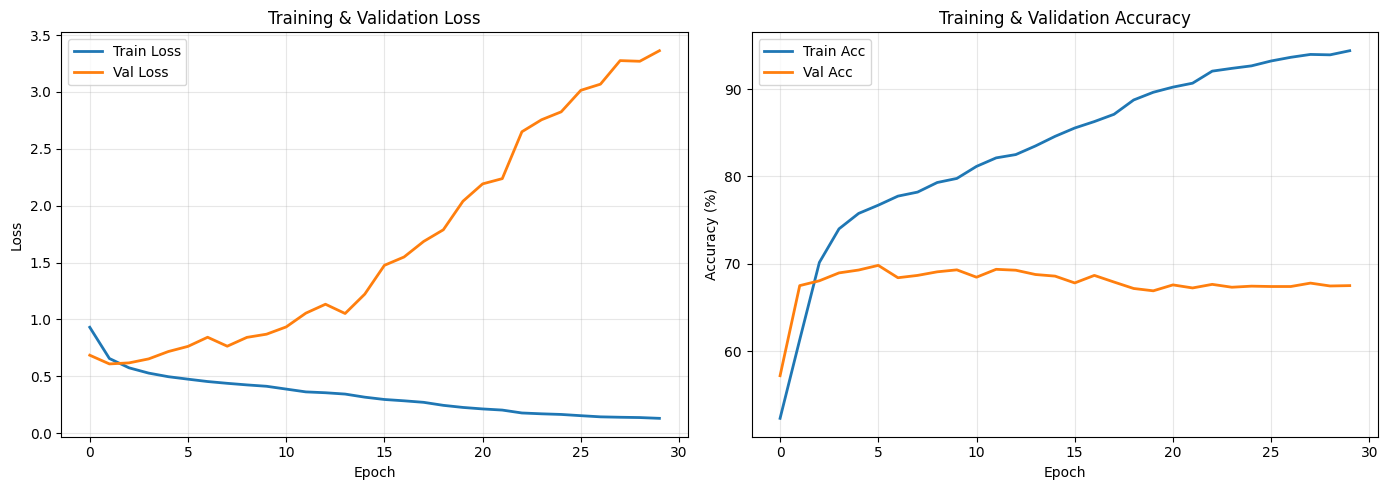

Training curves saved.


In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(train_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot([a * 100 for a in train_history['train_acc']], label='Train Acc', linewidth=2)
axes[1].plot([a * 100 for a in train_history['val_acc']], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")


# MODULE-6

11

In [ ]:

# Load best model
print("Loading best model for evaluation...")
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']} (val acc: {checkpoint['val_acc']*100:.2f}%)")

val_loss, val_acc, type_acc = evaluate(model, val_loader, criterion, device)

print(f"\n{'=' * 70}")
print(f"FINAL EVALUATION RESULTS")
print(f"{'=' * 70}")
print(f"  Overall Accuracy : {val_acc * 100:.2f}%")
print(f"  Validation Loss  : {val_loss:.4f}")
print(f"\n  Per Answer-Type Accuracy:")
for atype, acc in sorted(type_acc.items()):
    print(f"    {atype:15s}: {acc * 100:.2f}%")

Loading best model for evaluation...
Loaded model from epoch 6 (val acc: 69.83%)

FINAL EVALUATION RESULTS
  Overall Accuracy : 69.83%
  Validation Loss  : 0.7636

  Per Answer-Type Accuracy:
    yes/no         : 69.83%


12

In [ ]:

@torch.no_grad()
def predict_answer(
    model,
    image_id: int,
    question: str,
    cnn_feature_map: Dict,
    clip_feature_map: Dict,
    tokenizer: SimpleTokenizer,
    idx_to_answer: Dict,
    top_k: int = 5
) -> List[Tuple[str, float]]:
    """Predict top-k answers for a given image + question pair."""
    model.eval()

    if image_id not in cnn_feature_map or image_id not in clip_feature_map:
        print(f"Error: Image {image_id} features not found.")
        return []

    cnn_feat = torch.FloatTensor(cnn_feature_map[image_id]).unsqueeze(0).to(device)
    clip_feat = torch.FloatTensor(clip_feature_map[image_id]).unsqueeze(0).to(device)

    cleaned_q = clean_question(question)
    q_encoded = tokenizer.encode(cleaned_q)
    q_tensor = torch.LongTensor(q_encoded).unsqueeze(0).to(device)

    logits = model(cnn_feat, clip_feat, q_tensor)
    probs = torch.softmax(logits, dim=-1).squeeze()

    top_probs, top_indices = probs.topk(top_k)

    results = []
    for prob, idx in zip(top_probs.cpu().numpy(), top_indices.cpu().numpy()):
        answer = idx_to_answer.get(int(idx), "<unknown>")
        results.append((answer, float(prob)))

    return results


print("=" * 70)
print("DEMO: VQA PREDICTIONS")
print("=" * 70)

# Pick some sample annotations from the validation set
sample_indices = list(range(0, min(10, len(val_dataset))))

for i in sample_indices:
    sample = full_dataset.samples[val_dataset.indices[i]]
    img_id = sample['image_id']
    q_id = sample['question_id']
    true_answer_idx = sample['answer_idx']
    true_answer = idx_to_answer[true_answer_idx]
    question_text = question_map[q_id]['question']

    predictions = predict_answer(
        model, img_id, question_text,
        cnn_feature_map, clip_feature_map,
        tokenizer, idx_to_answer, top_k=5
    )

    print(f"\n  Image ID : {img_id}")
    print(f"  Question : {question_text}")
    print(f"  True Ans : {true_answer}")
    print(f"  Predicted:")
    for rank, (ans, prob) in enumerate(predictions, 1):
        marker = " ✓" if ans == true_answer else ""
        print(f"    {rank}. {ans:20s} ({prob*100:.1f}%){marker}")

print(f"\n{'=' * 70}")
print("Ensemble VQA Model — Complete!")
print(f"{'=' * 70}")


DEMO: VQA PREDICTIONS

  Image ID : 19495
  Question : Is there a jump rope in the picture?
  True Ans : yes
  Predicted:
    1. yes                  (99.7%) ✓
    2. no                   (0.3%)
    3. <unknown>            (0.0%)
    4. <unknown>            (0.0%)
    5. <unknown>            (0.0%)

  Image ID : 4382
  Question : Is she alone?
  True Ans : yes
  Predicted:
    1. yes                  (99.8%) ✓
    2. no                   (0.2%)
    3. <unknown>            (0.0%)
    4. <unknown>            (0.0%)
    5. <unknown>            (0.0%)

  Image ID : 5854
  Question : Does the girls shirt match the sidewalk?
  True Ans : yes
  Predicted:
    1. yes                  (99.8%) ✓
    2. no                   (0.2%)
    3. <unknown>            (0.0%)
    4. <unknown>            (0.0%)
    5. <unknown>            (0.0%)

  Image ID : 7952
  Question : Do both chairs have a pillow?
  True Ans : no
  Predicted:
    1. yes                  (94.4%)
    2. no                   (5.6%) ✓
 

# Comparision between different Models

Defined: CNNOnlyVQAModel, CNNOnlyAttentionVQAModel, CLIPOnlyVQAModel, EnsembleNoAttentionVQAModel
CNN-Only model: 8,784,456 parameters

Training: CNN-Only (ResNet50)
  Epoch 01/30 │ Train: 0.8449 / 53.78% │ Val: 0.6827 / 57.20% ★
  Epoch 05/30 │ Train: 0.6857 / 56.53% │ Val: 0.6820 / 57.27% ★
  Epoch 10/30 │ Train: 0.6771 / 57.43% │ Val: 0.6980 / 57.20%
  Epoch 15/30 │ Train: 0.6630 / 60.40% │ Val: 0.7138 / 54.97%
  Epoch 20/30 │ Train: 0.6359 / 63.75% │ Val: 0.7582 / 53.19%
  Epoch 25/30 │ Train: 0.5957 / 67.98% │ Val: 0.8207 / 53.27%
  Epoch 30/30 │ Train: 0.5543 / 71.66% │ Val: 0.8887 / 52.26%
  Best val accuracy: 57.27%
Saved CNN-only model.
CNN-Only + Attention model: 9,571,912 parameters

Training: CNN-Only + Attention
  Epoch 01/30 │ Train: 0.8421 / 53.17% │ Val: 0.6513 / 62.74% ★
  Epoch 02/30 │ Train: 0.6260 / 65.18% │ Val: 0.6017 / 67.78% ★
  Epoch 03/30 │ Train: 0.5520 / 72.18% │ Val: 0.5966 / 68.31% ★
  Epoch 04/30 │ Train: 0.5133 / 74.86% │ Val: 0.7205 / 68.95% ★
  Epoch 0

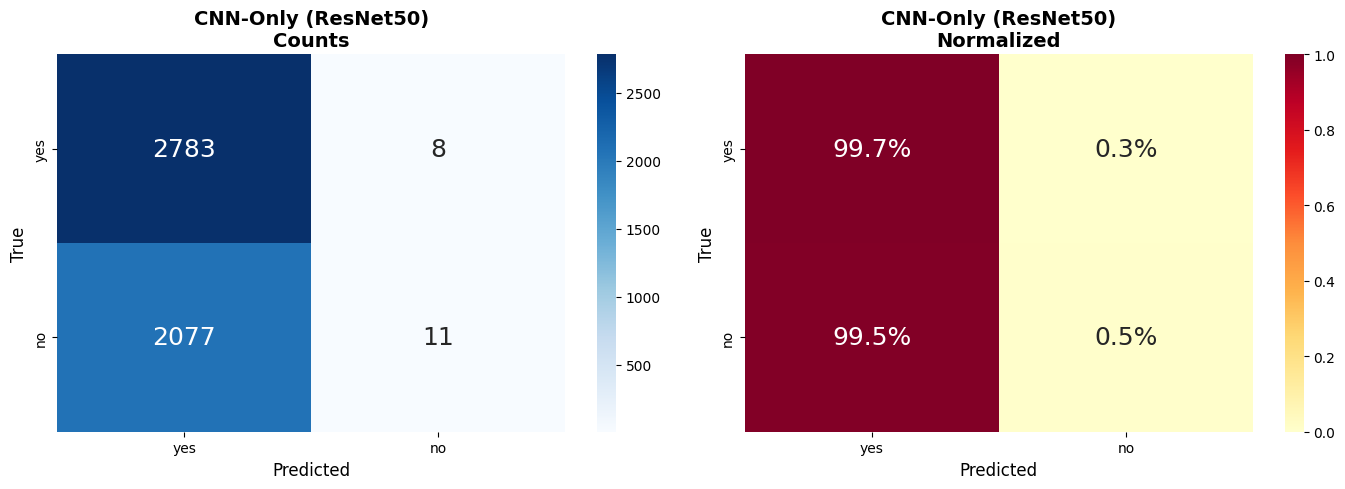


--- CNN-Only + Attention Model ---
  Saved: /content/drive/MyDrive/VQA_capstone_1/analysis_results/confusion_matrix_cnn_attention.png


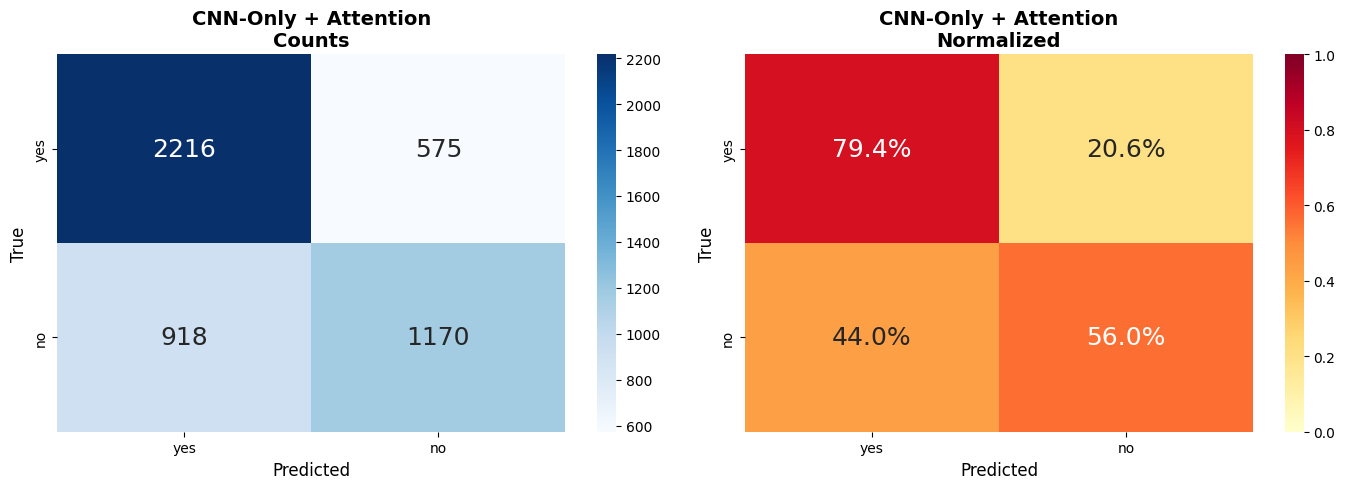


--- CLIP-Only Model ---
  Saved: /content/drive/MyDrive/VQA_capstone_1/analysis_results/confusion_matrix_clip_only.png


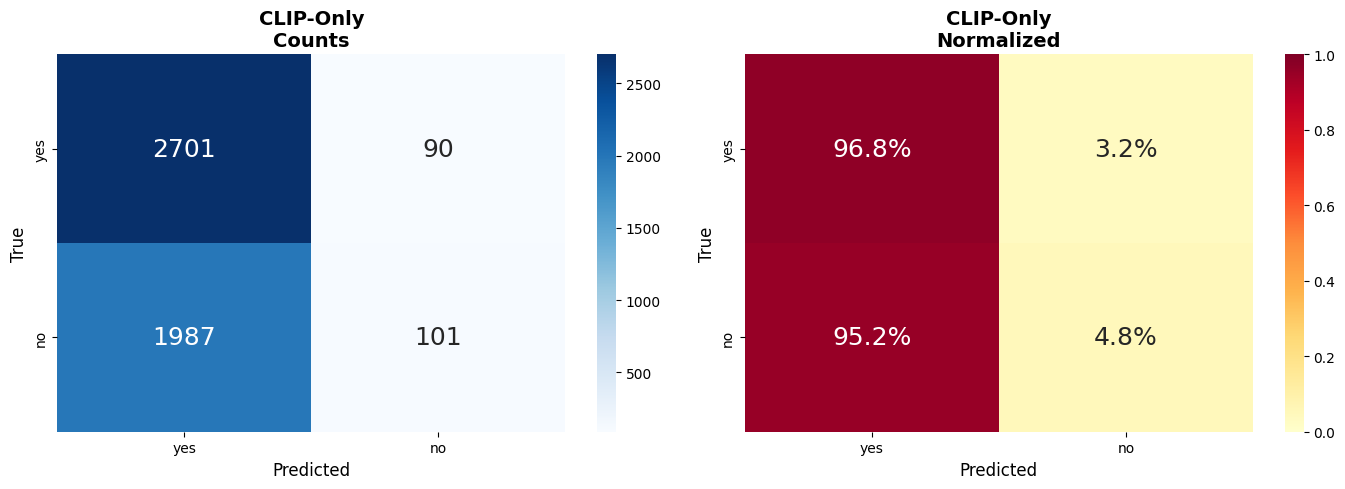


--- Ensemble (No Attention) Model ---
  Saved: /content/drive/MyDrive/VQA_capstone_1/analysis_results/confusion_matrix_ensemble_no_attn.png


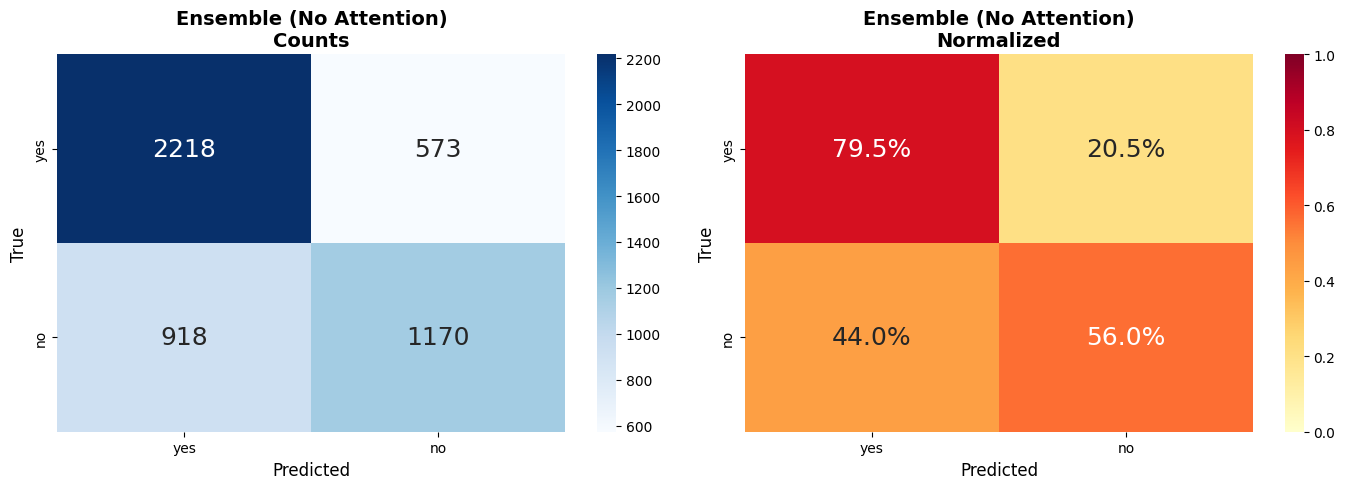


--- Ensemble + Attention Model ---
  Saved: /content/drive/MyDrive/VQA_capstone_1/analysis_results/confusion_matrix_ensemble_attention.png


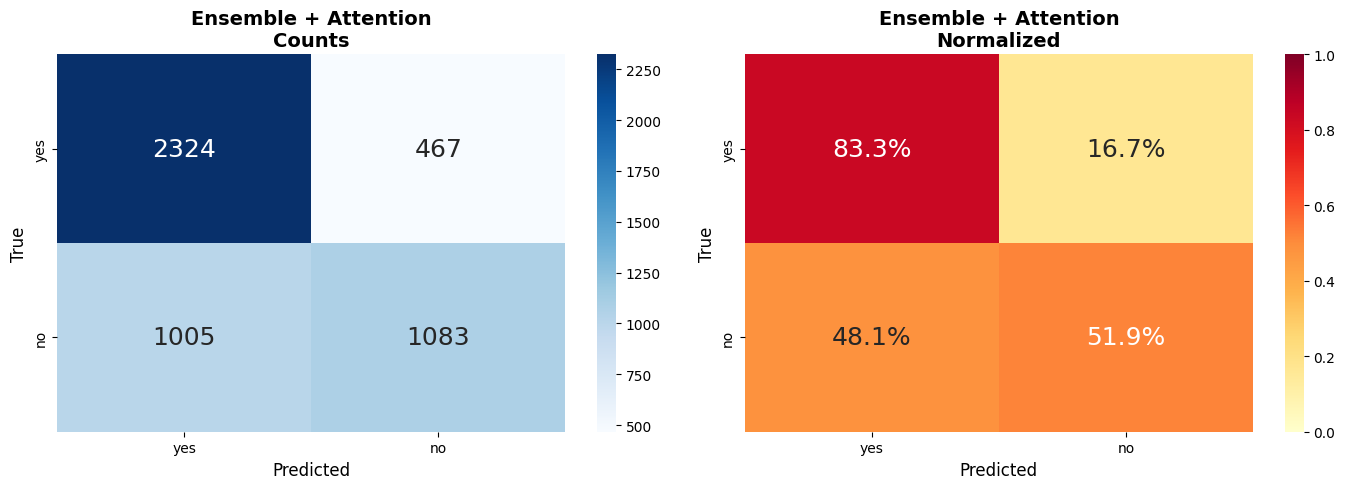

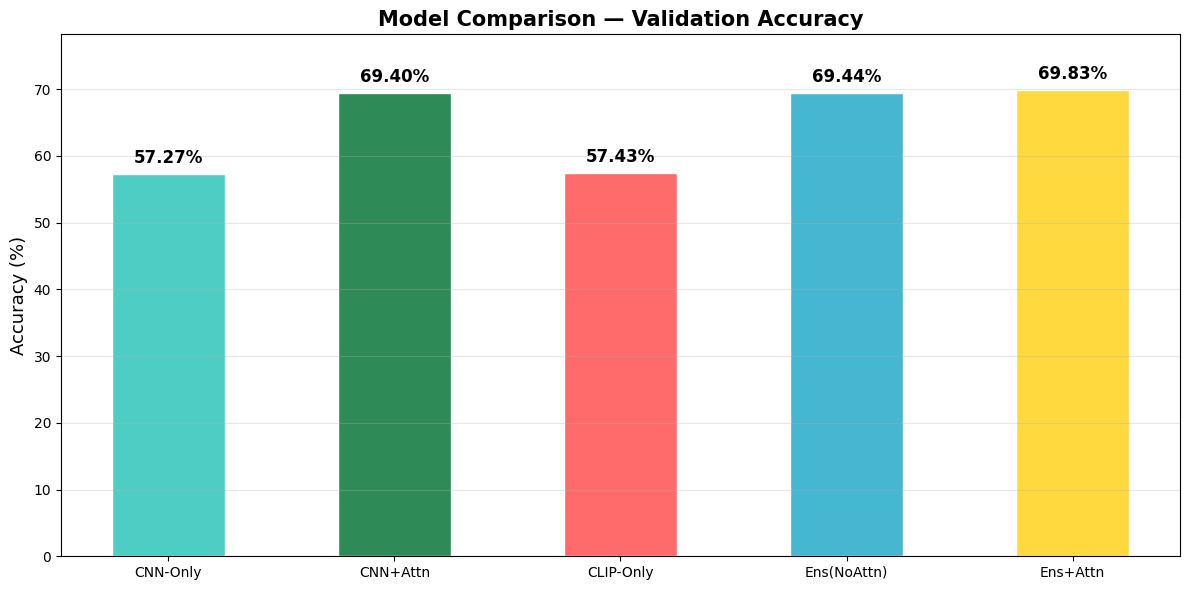

Saved accuracy comparison chart.


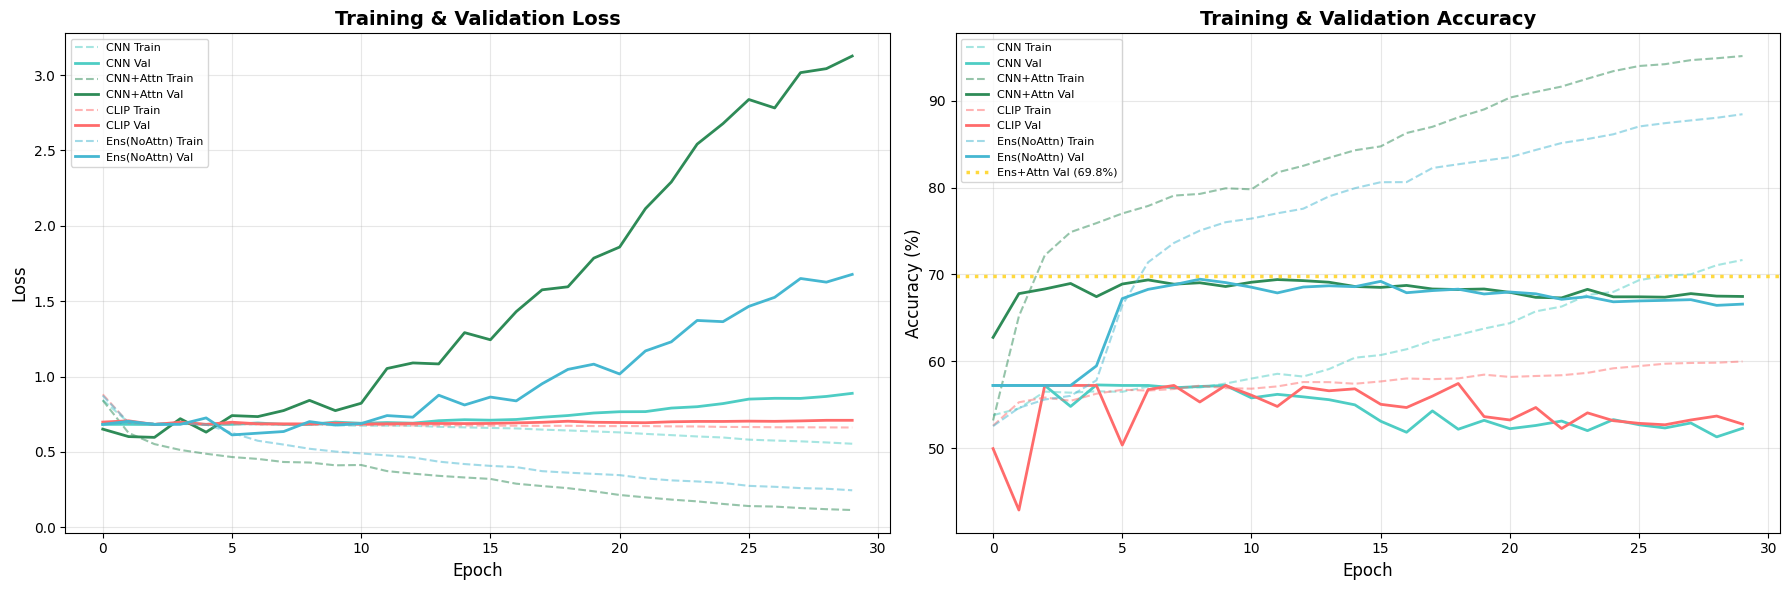

Saved training curves comparison.

CLASSIFICATION REPORT — CNN-Only
              precision    recall  f1-score   support

         yes       0.57      1.00      0.73      2791
          no       0.58      0.01      0.01      2088

    accuracy                           0.57      4879
   macro avg       0.58      0.50      0.37      4879
weighted avg       0.58      0.57      0.42      4879


CLASSIFICATION REPORT — CNN-Only + Attention
              precision    recall  f1-score   support

         yes       0.71      0.79      0.75      2791
          no       0.67      0.56      0.61      2088

    accuracy                           0.69      4879
   macro avg       0.69      0.68      0.68      4879
weighted avg       0.69      0.69      0.69      4879


CLASSIFICATION REPORT — CLIP-Only
              precision    recall  f1-score   support

         yes       0.58      0.97      0.72      2791
          no       0.53      0.05      0.09      2088

    accuracy                     

In [ ]:
############################################################
# CELL 1: Additional Imports for Analysis
# (Run in same notebook after ensemble_vqa_model.py cells)
############################################################

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

RESULTS_DIR = os.path.join(BASE_PATH, "analysis_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

!pip install seaborn scikit-learn


############################################################
# CELL 2: All Comparison Model Definitions
############################################################

class CNNOnlyVQAModel(nn.Module):
    """VQA model using ONLY CNN (ResNet50) features — no attention."""

    def __init__(self, vocab_size, num_answers, cnn_dim=CNN_FEATURE_DIM,
                 proj_dim=FUSED_IMAGE_DIM, embed_dim=QUESTION_EMBED_DIM,
                 hidden_dim=QUESTION_HIDDEN_DIM, fusion_dim=FUSION_DIM,
                 dropout=DROPOUT_RATE):
        super().__init__()
        self.image_projection = nn.Sequential(
            nn.Linear(cnn_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.question_projection = nn.Sequential(
            nn.Linear(hidden_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(fusion_dim, num_answers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.1)
                m.weight.data[0].fill_(0)

    def forward(self, cnn_features, clip_features, question):
        img = self.image_projection(cnn_features)
        emb = self.embedding(question)
        _, (h, _) = self.lstm(emb)
        q = self.question_projection(h[-1])
        fused = self.fusion(img * q)
        return self.classifier(fused)


class CNNOnlyAttentionVQAModel(nn.Module):
    """VQA model using ONLY CNN (ResNet50) features + Image-Guided Attention over LSTM."""

    def __init__(self, vocab_size, num_answers, cnn_dim=CNN_FEATURE_DIM,
                 proj_dim=FUSED_IMAGE_DIM, embed_dim=QUESTION_EMBED_DIM,
                 hidden_dim=QUESTION_HIDDEN_DIM, fusion_dim=FUSION_DIM,
                 dropout=DROPOUT_RATE):
        super().__init__()
        self.image_projection = nn.Sequential(
            nn.Linear(cnn_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        # Reuse the same ImageGuidedAttention class from ensemble_vqa_model.py
        self.attention = ImageGuidedAttention(
            image_dim=proj_dim,
            hidden_dim=hidden_dim,
            attn_dim=hidden_dim
        )
        self.question_projection = nn.Sequential(
            nn.Linear(hidden_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(fusion_dim, num_answers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.1)
                m.weight.data[0].fill_(0)

    def forward(self, cnn_features, clip_features, question):
        img = self.image_projection(cnn_features)
        emb = self.embedding(question)
        lstm_out, _ = self.lstm(emb)
        pad_mask = (question == 0)
        context, _ = self.attention(img, lstm_out, pad_mask)
        q = self.question_projection(context)
        fused = self.fusion(img * q)
        return self.classifier(fused)


class CLIPOnlyVQAModel(nn.Module):
    """VQA model using ONLY CLIP features."""

    def __init__(self, vocab_size, num_answers, clip_dim=CLIP_FEATURE_DIM,
                 proj_dim=FUSED_IMAGE_DIM, embed_dim=QUESTION_EMBED_DIM,
                 hidden_dim=QUESTION_HIDDEN_DIM, fusion_dim=FUSION_DIM,
                 dropout=DROPOUT_RATE):
        super().__init__()
        self.image_projection = nn.Sequential(
            nn.Linear(clip_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.question_projection = nn.Sequential(
            nn.Linear(hidden_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(fusion_dim, num_answers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.1)
                m.weight.data[0].fill_(0)

    def forward(self, cnn_features, clip_features, question):
        img = self.image_projection(clip_features)
        emb = self.embedding(question)
        _, (h, _) = self.lstm(emb)
        q = self.question_projection(h[-1])
        fused = self.fusion(img * q)
        return self.classifier(fused)


class EnsembleNoAttentionVQAModel(nn.Module):
    """Ensemble VQA model (CNN+CLIP) WITHOUT attention — uses last LSTM hidden state only."""

    def __init__(self, vocab_size, num_answers, cnn_dim=CNN_FEATURE_DIM,
                 clip_dim=CLIP_FEATURE_DIM, fused_image_dim=FUSED_IMAGE_DIM,
                 embed_dim=QUESTION_EMBED_DIM, hidden_dim=QUESTION_HIDDEN_DIM,
                 num_lstm_layers=NUM_LSTM_LAYERS, fusion_dim=FUSION_DIM,
                 dropout=DROPOUT_RATE):
        super().__init__()
        concat_dim = cnn_dim + clip_dim
        self.image_projection = nn.Sequential(
            nn.Linear(concat_dim, fused_image_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(fused_image_dim)
        )
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_lstm_layers,
                            batch_first=True,
                            dropout=dropout if num_lstm_layers > 1 else 0)
        self.question_projection = nn.Sequential(
            nn.Linear(hidden_dim, fused_image_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(fused_image_dim)
        )
        self.fusion = nn.Sequential(
            nn.Linear(fused_image_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(fusion_dim, num_answers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.1)
                m.weight.data[0].fill_(0)

    def forward(self, cnn_features, clip_features, question):
        img_concat = torch.cat([cnn_features, clip_features], dim=-1)
        img = self.image_projection(img_concat)
        emb = self.embedding(question)
        _, (h, _) = self.lstm(emb)
        q = self.question_projection(h[-1])
        fused = self.fusion(img * q)
        return self.classifier(fused)


print("Defined: CNNOnlyVQAModel, CNNOnlyAttentionVQAModel, CLIPOnlyVQAModel, EnsembleNoAttentionVQAModel")


############################################################
# CELL 3: Training & Evaluation Helpers
############################################################

def train_one_epoch_compare(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        cnn_feat = batch['cnn_features'].to(device)
        clip_feat = batch['clip_features'].to(device)
        question = batch['question'].to(device)
        answer = batch['answer'].to(device)

        optimizer.zero_grad()
        logits = model(cnn_feat, clip_feat, question)
        loss = criterion(logits, answer)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * answer.size(0)
        correct += (logits.argmax(-1) == answer).sum().item()
        total += answer.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def full_evaluate(model, loader, criterion, idx_to_answer):
    """Full evaluation returning predictions, labels, and per-type metrics."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    all_preds, all_labels = [], []
    all_pred_texts, all_label_texts = [], []
    all_answer_types, all_question_types = [], []
    type_correct, type_total = Counter(), Counter()
    qtype_correct, qtype_total = Counter(), Counter()

    for batch in loader:
        cnn_feat = batch['cnn_features'].to(device)
        clip_feat = batch['clip_features'].to(device)
        question = batch['question'].to(device)
        answer = batch['answer'].to(device)
        answer_types = batch['answer_type']
        question_types = batch['question_type']

        logits = model(cnn_feat, clip_feat, question)
        loss = criterion(logits, answer)

        running_loss += loss.item() * answer.size(0)
        preds = logits.argmax(-1)
        matches = (preds == answer)
        correct += matches.sum().item()
        total += answer.size(0)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(answer.cpu().numpy().tolist())
        all_pred_texts.extend([idx_to_answer.get(p, '<unk>') for p in preds.cpu().numpy()])
        all_label_texts.extend([idx_to_answer.get(a, '<unk>') for a in answer.cpu().numpy()])
        all_answer_types.extend(answer_types)
        all_question_types.extend(question_types)

        for i, atype in enumerate(answer_types):
            type_total[atype] += 1
            if matches[i].item(): type_correct[atype] += 1
        for i, qtype in enumerate(question_types):
            qtype_total[qtype] += 1
            if matches[i].item(): qtype_correct[qtype] += 1

    return {
        'loss': running_loss / total,
        'accuracy': correct / total,
        'all_preds': all_preds,
        'all_labels': all_labels,
        'all_pred_texts': all_pred_texts,
        'all_label_texts': all_label_texts,
        'all_answer_types': all_answer_types,
        'all_question_types': all_question_types,
        'per_answer_type_acc': {t: type_correct[t] / type_total[t] for t in type_total},
        'per_answer_type_count': dict(type_total),
        'per_question_type_acc': {t: qtype_correct[t] / qtype_total[t] for t in qtype_total},
        'per_question_type_count': dict(qtype_total),
    }


def train_model_compare(model, model_name, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """Train a model and return the best version + history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    best_val_acc = 0.0
    best_state = None
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch_compare(model, train_loader, criterion, optimizer)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                cnn_feat = batch['cnn_features'].to(device)
                clip_feat = batch['clip_features'].to(device)
                question = batch['question'].to(device)
                answer = batch['answer'].to(device)
                logits = model(cnn_feat, clip_feat, question)
                loss = criterion(logits, answer)
                val_loss += loss.item() * answer.size(0)
                val_correct += (logits.argmax(-1) == answer).sum().item()
                val_total += answer.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        scheduler.step(val_acc)

        marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            marker = " ★"

        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f"  Epoch {epoch:02d}/{num_epochs} │ "
                  f"Train: {train_loss:.4f} / {train_acc*100:.2f}% │ "
                  f"Val: {val_loss:.4f} / {val_acc*100:.2f}%{marker}")

    print(f"  Best val accuracy: {best_val_acc*100:.2f}%")
    model.load_state_dict(best_state)
    model.to(device)
    return model, history, best_val_acc


############################################################
# CELL 4: Train CNN-Only Model
############################################################

cnn_model = CNNOnlyVQAModel(
    vocab_size=tokenizer.vocab_size,
    num_answers=TOP_K_ANSWERS
).to(device)

params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN-Only model: {params:,} parameters")

cnn_model, cnn_history, cnn_best_acc = train_model_compare(
    cnn_model, "CNN-Only (ResNet50)", train_loader, val_loader, num_epochs=NUM_EPOCHS
)

torch.save(cnn_model.state_dict(), os.path.join(MODEL_SAVE_DIR, "cnn_only_vqa_model.pth"))
print("Saved CNN-only model.")


############################################################
# CELL 5: Train CNN-Only + Attention Model
############################################################

cnn_attn_model = CNNOnlyAttentionVQAModel(
    vocab_size=tokenizer.vocab_size,
    num_answers=TOP_K_ANSWERS
).to(device)

params = sum(p.numel() for p in cnn_attn_model.parameters())
print(f"CNN-Only + Attention model: {params:,} parameters")

cnn_attn_model, cnn_attn_history, cnn_attn_best_acc = train_model_compare(
    cnn_attn_model, "CNN-Only + Attention", train_loader, val_loader, num_epochs=NUM_EPOCHS
)

torch.save(cnn_attn_model.state_dict(), os.path.join(MODEL_SAVE_DIR, "cnn_attention_vqa_model.pth"))
print("Saved CNN-Only + Attention model.")


############################################################
# CELL 6: Train CLIP-Only Model
############################################################

clip_only_model = CLIPOnlyVQAModel(
    vocab_size=tokenizer.vocab_size,
    num_answers=TOP_K_ANSWERS
).to(device)

params = sum(p.numel() for p in clip_only_model.parameters())
print(f"CLIP-Only model: {params:,} parameters")

clip_only_model, clip_history, clip_best_acc = train_model_compare(
    clip_only_model, "CLIP-Only", train_loader, val_loader, num_epochs=NUM_EPOCHS
)

torch.save(clip_only_model.state_dict(), os.path.join(MODEL_SAVE_DIR, "clip_only_vqa_model.pth"))
print("Saved CLIP-only model.")


############################################################
# CELL 7: Train Ensemble-No-Attention Model
############################################################

ens_no_attn_model = EnsembleNoAttentionVQAModel(
    vocab_size=tokenizer.vocab_size,
    num_answers=TOP_K_ANSWERS
).to(device)

params = sum(p.numel() for p in ens_no_attn_model.parameters())
print(f"Ensemble (No Attention) model: {params:,} parameters")

ens_no_attn_model, ens_no_attn_history, ens_no_attn_best_acc = train_model_compare(
    ens_no_attn_model, "Ensemble (No Attention)", train_loader, val_loader, num_epochs=NUM_EPOCHS
)

torch.save(ens_no_attn_model.state_dict(), os.path.join(MODEL_SAVE_DIR, "ensemble_no_attention_vqa_model.pth"))
print("Saved Ensemble (No Attention) model.")


############################################################
# CELL 8: Reload Best Ensemble+Attention Model
############################################################

# The 'model' variable holds the EnsembleVQAModel (with attention)
# from ensemble_vqa_model.py — reload its best checkpoint
print("Reloading best Ensemble+Attention model...")
checkpoint = torch.load(
    os.path.join(MODEL_SAVE_DIR, "best_ensemble_vqa_model.pth"),
    map_location=device
)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Loaded from epoch {checkpoint.get('epoch', '?')} "
          f"(val acc: {checkpoint.get('val_acc', 0)*100:.2f}%)")
else:
    model.load_state_dict(checkpoint)
    print("  Loaded state dict.")


############################################################
# CELL 9: Full Evaluation — All 5 Models
############################################################

# Need the Dataset to return question_type and answer_type
# Rebuild val_loader to include these fields
class VQADatasetFull(Dataset):
    """Extended dataset that also returns question_type for analysis."""
    def __init__(self, base_dataset, indices):
        self.base = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample = self.base.samples[self.indices[idx]]
        return {
            'cnn_features': torch.FloatTensor(sample['cnn_features']),
            'clip_features': torch.FloatTensor(sample['clip_features']),
            'question': torch.LongTensor(sample['question']),
            'answer': torch.LongTensor([sample['answer_idx']]).squeeze(),
            'answer_type': sample['answer_type'],
            'question_type': sample.get('question_type', 'unknown')
        }

# Check if the base dataset has question_type stored
# If not, we need to add it
if not hasattr(full_dataset.samples[0], '__contains__') or 'question_type' not in full_dataset.samples[0]:
    # Rebuild with question_type from annotations
    print("Adding question_type to dataset samples...")
    ann_map = {ann.get('question_id'): ann.get('question_type', 'unknown') for ann in annotations_list}
    for sample in full_dataset.samples:
        if 'question_type' not in sample:
            sample['question_type'] = ann_map.get(sample['question_id'], 'unknown')
    print("  Done.")

analysis_val_dataset = VQADatasetFull(full_dataset, val_dataset.indices)
analysis_val_loader = DataLoader(analysis_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

criterion_eval = nn.CrossEntropyLoss()

print("\nEvaluating all 5 models on validation set...")
print("  Evaluating CNN-Only...")
cnn_results = full_evaluate(cnn_model, analysis_val_loader, criterion_eval, idx_to_answer)
print("  Evaluating CNN-Only + Attention...")
cnn_attn_results = full_evaluate(cnn_attn_model, analysis_val_loader, criterion_eval, idx_to_answer)
print("  Evaluating CLIP-Only...")
clip_results = full_evaluate(clip_only_model, analysis_val_loader, criterion_eval, idx_to_answer)
print("  Evaluating Ensemble (No Attention)...")
ens_no_attn_results = full_evaluate(ens_no_attn_model, analysis_val_loader, criterion_eval, idx_to_answer)
print("  Evaluating Ensemble+Attention...")
ensemble_attn_results = full_evaluate(model, analysis_val_loader, criterion_eval, idx_to_answer)

# ── Summary Table ──────────────────────────────────────────
print(f"\n{'=' * 95}")
print("MODEL COMPARISON — OVERALL ACCURACY")
print(f"{'=' * 95}")
print(f"  {'Model':<30} {'Val Loss':>10} {'Val Acc':>10} {'Params':>15}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*15}")

all_models_info = [
    ("CNN-Only (ResNet50)", cnn_results, cnn_model),
    ("CNN-Only + Attention", cnn_attn_results, cnn_attn_model),
    ("CLIP-Only", clip_results, clip_only_model),
    ("Ensemble (No Attention)", ens_no_attn_results, ens_no_attn_model),
    ("Ensemble + Attention", ensemble_attn_results, model),
]

for name, results, mdl in all_models_info:
    print(f"  {name:<30} {results['loss']:>10.4f} {results['accuracy']*100:>9.2f}% "
          f"{sum(p.numel() for p in mdl.parameters()):>15,}")

# ── Per Answer-Type Comparison ─────────────────────────────
all_results_dict = {
    'CNN-Only': cnn_results,
    'CNN+Attn': cnn_attn_results,
    'CLIP-Only': clip_results,
    'Ens(NoAttn)': ens_no_attn_results,
    'Ens+Attn': ensemble_attn_results,
}

all_answer_types = sorted(set(
    sum([list(r['per_answer_type_acc'].keys()) for r in all_results_dict.values()], [])
))

print(f"\n{'=' * 115}")
print("MODEL COMPARISON — PER ANSWER TYPE")
print(f"{'=' * 115}")
header_names = list(all_results_dict.keys())
print(f"  {'Answer Type':<15} {'Count':>7}", end="")
for h in header_names:
    print(f" {h:>12}", end="")
print(f" {'Best':>12}")
print(f"  {'-'*15} {'-'*7}", end="")
for _ in header_names:
    print(f" {'-'*12}", end="")
print(f" {'-'*12}")

for atype in all_answer_types:
    count = ensemble_attn_results['per_answer_type_count'].get(atype, 0)
    accs = {}
    for rname, r in all_results_dict.items():
        accs[rname] = r['per_answer_type_acc'].get(atype, 0) * 100
    best_acc = max(accs.values())
    best_name = [k for k, v in accs.items() if v == best_acc][0]
    print(f"  {atype:<15} {count:>7}", end="")
    for rname in header_names:
        print(f" {accs[rname]:>11.2f}%", end="")
    print(f" {best_name:>12}")



############################################################
# CELL 10: 2×2 Confusion Matrices (Yes / No) — All 5 Models
############################################################

def plot_2x2_confusion_matrix(y_true_texts, y_pred_texts, model_name, save_path=None):
    """Plot a simple 2×2 confusion matrix for yes/no predictions."""
    labels = ['yes', 'no']
    cm = confusion_matrix(y_true_texts, y_pred_texts, labels=labels)

    cm_norm = cm.astype(np.float64)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm_norm / row_sums

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[0], annot_kws={'size': 18})
    axes[0].set_title(f'{model_name}\nCounts', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('True', fontsize=12)

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels,
                ax=axes[1], vmin=0, vmax=1, annot_kws={'size': 18})
    axes[1].set_title(f'{model_name}\nNormalized', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted', fontsize=12)
    axes[1].set_ylabel('True', fontsize=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    plt.show()


print("=" * 70)
print("2×2 CONFUSION MATRICES (Yes / No)")
print("=" * 70)

cm_configs = [
    ("CNN-Only Model", cnn_results, "confusion_matrix_cnn_only.png", "CNN-Only (ResNet50)"),
    ("CNN-Only + Attention Model", cnn_attn_results, "confusion_matrix_cnn_attention.png", "CNN-Only + Attention"),
    ("CLIP-Only Model", clip_results, "confusion_matrix_clip_only.png", "CLIP-Only"),
    ("Ensemble (No Attention) Model", ens_no_attn_results, "confusion_matrix_ensemble_no_attn.png", "Ensemble (No Attention)"),
    ("Ensemble + Attention Model", ensemble_attn_results, "confusion_matrix_ensemble_attention.png", "Ensemble + Attention"),
]

for label, results, filename, title in cm_configs:
    print(f"\n--- {label} ---")
    plot_2x2_confusion_matrix(
        results['all_label_texts'], results['all_pred_texts'],
        title,
        save_path=os.path.join(RESULTS_DIR, filename)
    )


############################################################
# CELL 11: Overall Accuracy Bar Chart
############################################################

fig, ax = plt.subplots(figsize=(12, 6))

model_names = ['CNN-Only', 'CNN+Attn', 'CLIP-Only', 'Ens(NoAttn)', 'Ens+Attn']
accuracies = [
    cnn_results['accuracy'] * 100,
    cnn_attn_results['accuracy'] * 100,
    clip_results['accuracy'] * 100,
    ens_no_attn_results['accuracy'] * 100,
    ensemble_attn_results['accuracy'] * 100
]
colors = ['#4ECDC4', '#2E8B57', '#FF6B6B', '#45B7D1', '#FFD93D']

bars = ax.bar(model_names, accuracies, color=colors, edgecolor='white', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.annotate(f'{acc:.2f}%', xy=(bar.get_x() + bar.get_width()/2, acc),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Model Comparison — Validation Accuracy', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(accuracies) * 1.12)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "accuracy_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved accuracy comparison chart.")


############################################################
# CELL 12: Training Curves Comparison
############################################################

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

curve_configs = [
    ('CNN', cnn_history, '#4ECDC4'),
    ('CNN+Attn', cnn_attn_history, '#2E8B57'),
    ('CLIP', clip_history, '#FF6B6B'),
    ('Ens(NoAttn)', ens_no_attn_history, '#45B7D1'),
]

# Loss curves
for name, history, color in curve_configs:
    axes[0].plot(history['train_loss'], '--', label=f'{name} Train', alpha=0.5, linewidth=1.5, color=color)
    axes[0].plot(history['val_loss'], '-', label=f'{name} Val', linewidth=2, color=color)

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Accuracy curves
for name, history, color in curve_configs:
    axes[1].plot([a*100 for a in history['train_acc']], '--', label=f'{name} Train', alpha=0.5, linewidth=1.5, color=color)
    axes[1].plot([a*100 for a in history['val_acc']], '-', label=f'{name} Val', linewidth=2, color=color)

# Ensemble+Attention as horizontal line (since it was trained in ensemble_vqa_model.py)
axes[1].axhline(y=ensemble_attn_results['accuracy']*100, color='#FFD93D', linestyle=':',
                linewidth=2.5, label=f"Ens+Attn Val ({ensemble_attn_results['accuracy']*100:.1f}%)")

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved training curves comparison.")


############################################################
# CELL 13: Classification Reports (Yes / No)
############################################################

labels = ['yes', 'no']

for name, results in [
    ("CNN-Only", cnn_results),
    ("CNN-Only + Attention", cnn_attn_results),
    ("CLIP-Only", clip_results),
    ("Ensemble (No Attention)", ens_no_attn_results),
    ("Ensemble + Attention", ensemble_attn_results)
]:
    print(f"\n{'=' * 70}")
    print(f"CLASSIFICATION REPORT — {name}")
    print(f"{'=' * 70}")
    print(classification_report(
        results['all_label_texts'], results['all_pred_texts'],
        labels=labels, target_names=labels, zero_division=0
    ))


############################################################
# CELL 14: Final Summary & Verdict
############################################################

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

models_ranked = sorted([
    ("CNN-Only (ResNet50)", cnn_results['accuracy']),
    ("CNN-Only + Attention", cnn_attn_results['accuracy']),
    ("CLIP-Only", clip_results['accuracy']),
    ("Ensemble (No Attention)", ens_no_attn_results['accuracy']),
    ("Ensemble + Attention", ensemble_attn_results['accuracy']),
], key=lambda x: x[1], reverse=True)

print("\n  Overall Ranking:")
medals = ["🥇", "🥈", "🥉", "4️⃣", "5️⃣"]
for rank, (name, acc) in enumerate(models_ranked):
    print(f"    {medals[rank]} {rank+1}. {name:<30} {acc*100:.2f}%")

# Compare: CNN+Attention vs CNN (no attention)
cnn_overall = cnn_results['accuracy'] * 100
cnn_attn_overall = cnn_attn_results['accuracy'] * 100
cnn_attn_advantage = cnn_attn_overall - cnn_overall

print(f"\n  CNN Attention advantage over CNN (No Attention): {cnn_attn_advantage:+.2f}%")
if cnn_attn_advantage > 0:
    print("  ✅ Attention improved the CNN-only model!")
else:
    print("  ⚠️  Attention did NOT improve the CNN-only model.")

# Compare: Ensemble+Attention vs Ensemble (no attention)
attn_acc = ensemble_attn_results['accuracy'] * 100
no_attn_acc = ens_no_attn_results['accuracy'] * 100
attn_advantage = attn_acc - no_attn_acc

print(f"\n  Ensemble Attention advantage over Ensemble (No Attention): {attn_advantage:+.2f}%")
if attn_advantage > 0:
    print("  ✅ Attention improved the ensemble model!")
else:
    print("  ⚠️  Attention did NOT improve the ensemble model.")

# Compare: Best overall vs best single-feature model
clip_overall = clip_results['accuracy'] * 100
best_single = max(cnn_overall, cnn_attn_overall, clip_overall)
best_ensemble = max(attn_acc, no_attn_acc)
ens_advantage = best_ensemble - best_single

print(f"\n  Best ensemble advantage over best single-feature model: {ens_advantage:+.2f}%")
if ens_advantage > 0:
    print("  ✅ The ensemble IS better than individual models.")
else:
    print("  ⚠️  The ensemble did NOT outperform the best individual model.")
    print("     This may indicate one feature type dominates for this dataset.")

print(f"\n  All charts & confusion matrices saved to: {RESULTS_DIR}")
print("=" * 70)



## New Section

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

RESULTS_DIR = os.path.join(BASE_PATH, "analysis_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

!pip install seaborn scikit-learn

In [ ]:

class CNNOnlyVQAModel(nn.Module):
    """VQA model using ONLY CNN (ResNet50) features."""

    def __init__(self, vocab_size, num_answers, cnn_dim=CNN_FEATURE_DIM,
                 proj_dim=FUSED_IMAGE_DIM, embed_dim=QUESTION_EMBED_DIM,
                 hidden_dim=QUESTION_HIDDEN_DIM, fusion_dim=FUSION_DIM,
                 dropout=DROPOUT_RATE):
        super().__init__()
        self.image_projection = nn.Sequential(
            nn.Linear(cnn_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.question_projection = nn.Sequential(
            nn.Linear(hidden_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(fusion_dim, num_answers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.1)
                m.weight.data[0].fill_(0)

    def forward(self, cnn_features, clip_features, question):
        img = self.image_projection(cnn_features)
        emb = self.embedding(question)
        _, (h, _) = self.lstm(emb)
        q = self.question_projection(h[-1])
        fused = self.fusion(img * q)
        return self.classifier(fused)


class CLIPOnlyVQAModel(nn.Module):
    """VQA model using ONLY CLIP features."""

    def __init__(self, vocab_size, num_answers, clip_dim=CLIP_FEATURE_DIM,
                 proj_dim=FUSED_IMAGE_DIM, embed_dim=QUESTION_EMBED_DIM,
                 hidden_dim=QUESTION_HIDDEN_DIM, fusion_dim=FUSION_DIM,
                 dropout=DROPOUT_RATE):
        super().__init__()
        self.image_projection = nn.Sequential(
            nn.Linear(clip_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.question_projection = nn.Sequential(
            nn.Linear(hidden_dim, proj_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.LayerNorm(proj_dim)
        )
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim), nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(fusion_dim, num_answers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.1)
                m.weight.data[0].fill_(0)

    def forward(self, cnn_features, clip_features, question):
        img = self.image_projection(clip_features)
        emb = self.embedding(question)
        _, (h, _) = self.lstm(emb)
        q = self.question_projection(h[-1])
        fused = self.fusion(img * q)
        return self.classifier(fused)


print("Defined: CNNOnlyVQAModel, CLIPOnlyVQAModel")



Defined: CNNOnlyVQAModel, CLIPOnlyVQAModel


In [ ]:

def train_one_epoch_compare(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        cnn_feat = batch['cnn_features'].to(device)
        clip_feat = batch['clip_features'].to(device)
        question = batch['question'].to(device)
        answer = batch['answer'].to(device)

        optimizer.zero_grad()
        logits = model(cnn_feat, clip_feat, question)
        loss = criterion(logits, answer)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * answer.size(0)
        correct += (logits.argmax(-1) == answer).sum().item()
        total += answer.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def full_evaluate(model, loader, criterion, idx_to_answer):
    """Full evaluation returning predictions, labels, and per-type metrics."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    all_preds, all_labels = [], []
    all_pred_texts, all_label_texts = [], []
    all_answer_types, all_question_types = [], []
    type_correct, type_total = Counter(), Counter()
    qtype_correct, qtype_total = Counter(), Counter()

    for batch in loader:
        cnn_feat = batch['cnn_features'].to(device)
        clip_feat = batch['clip_features'].to(device)
        question = batch['question'].to(device)
        answer = batch['answer'].to(device)
        answer_types = batch['answer_type']
        question_types = batch['question_type']

        logits = model(cnn_feat, clip_feat, question)
        loss = criterion(logits, answer)

        running_loss += loss.item() * answer.size(0)
        preds = logits.argmax(-1)
        matches = (preds == answer)
        correct += matches.sum().item()
        total += answer.size(0)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(answer.cpu().numpy().tolist())
        all_pred_texts.extend([idx_to_answer.get(p, '<unk>') for p in preds.cpu().numpy()])
        all_label_texts.extend([idx_to_answer.get(a, '<unk>') for a in answer.cpu().numpy()])
        all_answer_types.extend(answer_types)
        all_question_types.extend(question_types)

        for i, atype in enumerate(answer_types):
            type_total[atype] += 1
            if matches[i].item(): type_correct[atype] += 1
        for i, qtype in enumerate(question_types):
            qtype_total[qtype] += 1
            if matches[i].item(): qtype_correct[qtype] += 1

    return {
        'loss': running_loss / total,
        'accuracy': correct / total,
        'all_preds': all_preds,
        'all_labels': all_labels,
        'all_pred_texts': all_pred_texts,
        'all_label_texts': all_label_texts,
        'all_answer_types': all_answer_types,
        'all_question_types': all_question_types,
        'per_answer_type_acc': {t: type_correct[t] / type_total[t] for t in type_total},
        'per_answer_type_count': dict(type_total),
        'per_question_type_acc': {t: qtype_correct[t] / qtype_total[t] for t in qtype_total},
        'per_question_type_count': dict(qtype_total),
    }


def train_model_compare(model, model_name, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """Train a model and return the best version + history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    best_val_acc = 0.0
    best_state = None
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch_compare(model, train_loader, criterion, optimizer)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                cnn_feat = batch['cnn_features'].to(device)
                clip_feat = batch['clip_features'].to(device)
                question = batch['question'].to(device)
                answer = batch['answer'].to(device)
                logits = model(cnn_feat, clip_feat, question)
                loss = criterion(logits, answer)
                val_loss += loss.item() * answer.size(0)
                val_correct += (logits.argmax(-1) == answer).sum().item()
                val_total += answer.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        scheduler.step(val_acc)

        marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            marker = " ★"

        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f"  Epoch {epoch:02d}/{num_epochs} │ "
                  f"Train: {train_loss:.4f} / {train_acc*100:.2f}% │ "
                  f"Val: {val_loss:.4f} / {val_acc*100:.2f}%{marker}")

    print(f"  Best val accuracy: {best_val_acc*100:.2f}%")
    model.load_state_dict(best_state)
    model.to(device)
    return model, history, best_val_acc



In [ ]:

cnn_model = CNNOnlyVQAModel(
    vocab_size=tokenizer.vocab_size,
    num_answers=TOP_K_ANSWERS
).to(device)

params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN-Only model: {params:,} parameters")

cnn_model, cnn_history, cnn_best_acc = train_model_compare(
    cnn_model, "CNN-Only (ResNet50)", train_loader, val_loader, num_epochs=NUM_EPOCHS
)

torch.save(cnn_model.state_dict(), os.path.join(MODEL_SAVE_DIR, "cnn_only_vqa_model.pth"))
print("Saved CNN-only model.")


CNN-Only model: 8,784,456 parameters

Training: CNN-Only (ResNet50)
  Epoch 01/30 │ Train: 0.8709 / 53.16% │ Val: 0.7018 / 57.20% ★
  Epoch 04/30 │ Train: 0.6712 / 59.11% │ Val: 0.6328 / 65.51% ★
  Epoch 05/30 │ Train: 0.6047 / 67.98% │ Val: 0.6884 / 65.22%
  Epoch 06/30 │ Train: 0.5614 / 71.94% │ Val: 0.6631 / 69.03% ★
  Epoch 10/30 │ Train: 0.4766 / 76.43% │ Val: 0.7175 / 69.30% ★
  Epoch 15/30 │ Train: 0.4093 / 80.19% │ Val: 0.8596 / 68.17%
  Epoch 20/30 │ Train: 0.3360 / 83.96% │ Val: 1.0516 / 67.64%
  Epoch 25/30 │ Train: 0.2639 / 87.71% │ Val: 1.4160 / 67.29%
  Epoch 30/30 │ Train: 0.2154 / 89.83% │ Val: 1.7937 / 66.35%
  Best val accuracy: 69.30%
Saved CNN-only model.


In [ ]:

clip_only_model = CLIPOnlyVQAModel(
    vocab_size=tokenizer.vocab_size,
    num_answers=TOP_K_ANSWERS
).to(device)

params = sum(p.numel() for p in clip_only_model.parameters())
print(f"CLIP-Only model: {params:,} parameters")

clip_only_model, clip_history, clip_best_acc = train_model_compare(
    clip_only_model, "CLIP-Only", train_loader, val_loader, num_epochs=NUM_EPOCHS
)

torch.save(clip_only_model.state_dict(), os.path.join(MODEL_SAVE_DIR, "clip_only_vqa_model.pth"))
print("Saved CLIP-only model.")



CLIP-Only model: 7,211,592 parameters

Training: CLIP-Only
  Epoch 01/30 │ Train: 0.8331 / 53.90% │ Val: 0.7102 / 57.20% ★
  Epoch 05/30 │ Train: 0.6845 / 56.28% │ Val: 0.6893 / 57.20%
  Epoch 10/30 │ Train: 0.6798 / 56.99% │ Val: 0.6850 / 56.32%
  Epoch 15/30 │ Train: 0.6762 / 57.62% │ Val: 0.6881 / 56.61%
  Epoch 20/30 │ Train: 0.6734 / 58.01% │ Val: 0.6972 / 56.53%
  Epoch 25/30 │ Train: 0.6714 / 58.07% │ Val: 0.6953 / 55.22%
  Epoch 30/30 │ Train: 0.6709 / 57.85% │ Val: 0.6963 / 54.42%
  Best val accuracy: 57.20%
Saved CLIP-only model.


In [ ]:
print("Reloading best ensemble model...")
checkpoint = torch.load(
    os.path.join(MODEL_SAVE_DIR, "best_ensemble_vqa_model.pth"),
    map_location=device
)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Loaded from epoch {checkpoint.get('epoch', '?')} "
          f"(val acc: {checkpoint.get('val_acc', 0)*100:.2f}%)")
else:
    model.load_state_dict(checkpoint)
    print("  Loaded state dict.")


Reloading best ensemble model...
  Loaded from epoch 13 (val acc: 68.46%)


In [ ]:
class VQADatasetFull(Dataset):
    """Extended dataset that also returns question_type for analysis."""
    def __init__(self, base_dataset, indices):
        self.base = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample = self.base.samples[self.indices[idx]]
        return {
            'cnn_features': torch.FloatTensor(sample['cnn_features']),
            'clip_features': torch.FloatTensor(sample['clip_features']),
            'question': torch.LongTensor(sample['question']),
            'answer': torch.LongTensor([sample['answer_idx']]).squeeze(),
            'answer_type': sample['answer_type'],
            'question_type': sample.get('question_type', 'unknown')
        }

# Check if the base dataset has question_type stored
# If not, we need to add it
if not hasattr(full_dataset.samples[0], '__contains__') or 'question_type' not in full_dataset.samples[0]:
    # Rebuild with question_type from annotations
    print("Adding question_type to dataset samples...")
    ann_map = {ann.get('question_id'): ann.get('question_type', 'unknown') for ann in annotations_list}
    for sample in full_dataset.samples:
        if 'question_type' not in sample:
            sample['question_type'] = ann_map.get(sample['question_id'], 'unknown')
    print("  Done.")

analysis_val_dataset = VQADatasetFull(full_dataset, val_dataset.indices)
analysis_val_loader = DataLoader(analysis_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

criterion_eval = nn.CrossEntropyLoss()

print("\nEvaluating all 3 models on validation set...")
print("  Evaluating CNN-Only...")
cnn_results = full_evaluate(cnn_model, analysis_val_loader, criterion_eval, idx_to_answer)
print("  Evaluating CLIP-Only...")
clip_results = full_evaluate(clip_only_model, analysis_val_loader, criterion_eval, idx_to_answer)
print("  Evaluating Ensemble...")
ensemble_results = full_evaluate(model, analysis_val_loader, criterion_eval, idx_to_answer)

# ── Summary Table ──────────────────────────────────────────
print(f"\n{'=' * 80}")
print("MODEL COMPARISON — OVERALL ACCURACY")
print(f"{'=' * 80}")
print(f"  {'Model':<25} {'Val Loss':>10} {'Val Acc':>10} {'Params':>15}")
print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*15}")
print(f"  {'CNN-Only (ResNet50)':<25} {cnn_results['loss']:>10.4f} {cnn_results['accuracy']*100:>9.2f}% "
      f"{sum(p.numel() for p in cnn_model.parameters()):>15,}")
print(f"  {'CLIP-Only':<25} {clip_results['loss']:>10.4f} {clip_results['accuracy']*100:>9.2f}% "
      f"{sum(p.numel() for p in clip_only_model.parameters()):>15,}")
print(f"  {'Ensemble (CNN+CLIP)':<25} {ensemble_results['loss']:>10.4f} {ensemble_results['accuracy']*100:>9.2f}% "
      f"{sum(p.numel() for p in model.parameters()):>15,}")

# ── Per Answer-Type Comparison ─────────────────────────────
all_answer_types = sorted(set(
    list(cnn_results['per_answer_type_acc'].keys()) +
    list(clip_results['per_answer_type_acc'].keys()) +
    list(ensemble_results['per_answer_type_acc'].keys())
))

print(f"\n{'=' * 80}")
print("MODEL COMPARISON — PER ANSWER TYPE")
print(f"{'=' * 80}")
print(f"  {'Answer Type':<15} {'Count':>7} {'CNN-Only':>12} {'CLIP-Only':>12} {'Ensemble':>12} {'Best':>12}")
print(f"  {'-'*15} {'-'*7} {'-'*12} {'-'*12} {'-'*12} {'-'*12}")

for atype in all_answer_types:
    count = ensemble_results['per_answer_type_count'].get(atype, 0)
    cnn_acc = cnn_results['per_answer_type_acc'].get(atype, 0) * 100
    clip_acc = clip_results['per_answer_type_acc'].get(atype, 0) * 100
    ens_acc = ensemble_results['per_answer_type_acc'].get(atype, 0) * 100
    best_acc = max(cnn_acc, clip_acc, ens_acc)
    best_name = "Ensemble" if best_acc == ens_acc else ("CLIP" if best_acc == clip_acc else "CNN")
    print(f"  {atype:<15} {count:>7} {cnn_acc:>11.2f}% {clip_acc:>11.2f}% {ens_acc:>11.2f}% {best_name:>12}")

# ── Per Question-Type Comparison (top 15) ──────────────────
sorted_qtypes = sorted(
    ensemble_results['per_question_type_count'].items(),
    key=lambda x: x[1], reverse=True
)[:15]

print(f"\n{'=' * 80}")
print("MODEL COMPARISON — PER QUESTION TYPE (Top 15)")
print(f"{'=' * 80}")
print(f"  {'Question Type':<25} {'Count':>6} {'CNN':>9} {'CLIP':>9} {'Ensemble':>9} {'Best':>10}")
print(f"  {'-'*25} {'-'*6} {'-'*9} {'-'*9} {'-'*9} {'-'*10}")

for qtype, count in sorted_qtypes:
    cnn_acc = cnn_results['per_question_type_acc'].get(qtype, 0) * 100
    clip_acc = clip_results['per_question_type_acc'].get(qtype, 0) * 100
    ens_acc = ensemble_results['per_question_type_acc'].get(qtype, 0) * 100
    best_acc = max(cnn_acc, clip_acc, ens_acc)
    best_name = "Ensemble" if best_acc == ens_acc else ("CLIP" if best_acc == clip_acc else "CNN")
    print(f"  {qtype:<25} {count:>6} {cnn_acc:>8.2f}% {clip_acc:>8.2f}% {ens_acc:>8.2f}% {best_name:>10}")


Adding question_type to dataset samples...
  Done.

Evaluating all 3 models on validation set...
  Evaluating CNN-Only...
  Evaluating CLIP-Only...
  Evaluating Ensemble...

MODEL COMPARISON — OVERALL ACCURACY
  Model                       Val Loss    Val Acc          Params
  ------------------------- ---------- ---------- ---------------
  CNN-Only (ResNet50)           0.7175     69.30%       8,784,456
  CLIP-Only                     0.7102     57.20%       7,211,592
  Ensemble (CNN+CLIP)           0.6893     68.46%       9,308,744

MODEL COMPARISON — PER ANSWER TYPE
  Answer Type       Count     CNN-Only    CLIP-Only     Ensemble         Best
  --------------- ------- ------------ ------------ ------------ ------------
  yes/no             4879       69.30%       57.20%       68.46%          CNN

MODEL COMPARISON — PER QUESTION TYPE (Top 15)
  Question Type              Count       CNN      CLIP  Ensemble       Best
  ------------------------- ------ --------- --------- --------- --

2×2 CONFUSION MATRICES (Yes / No)

--- CNN-Only Model ---
  Saved: /content/drive/MyDrive/VQA_capstone_1/analysis_results/confusion_matrix_cnn_only.png


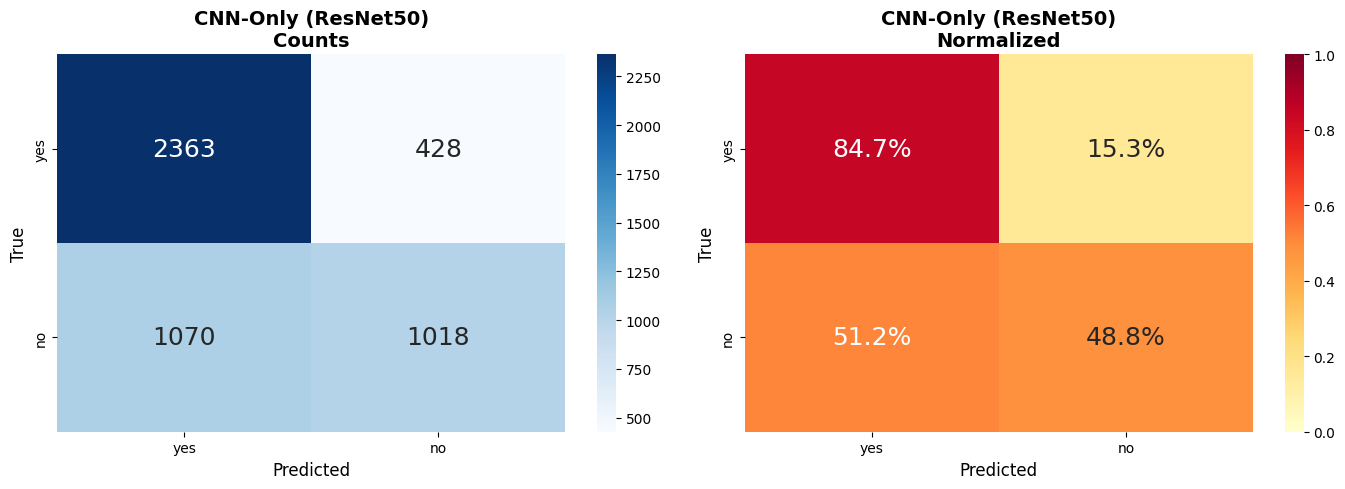


--- CLIP-Only Model ---
  Saved: /content/drive/MyDrive/VQA_capstone_1/analysis_results/confusion_matrix_clip_only.png


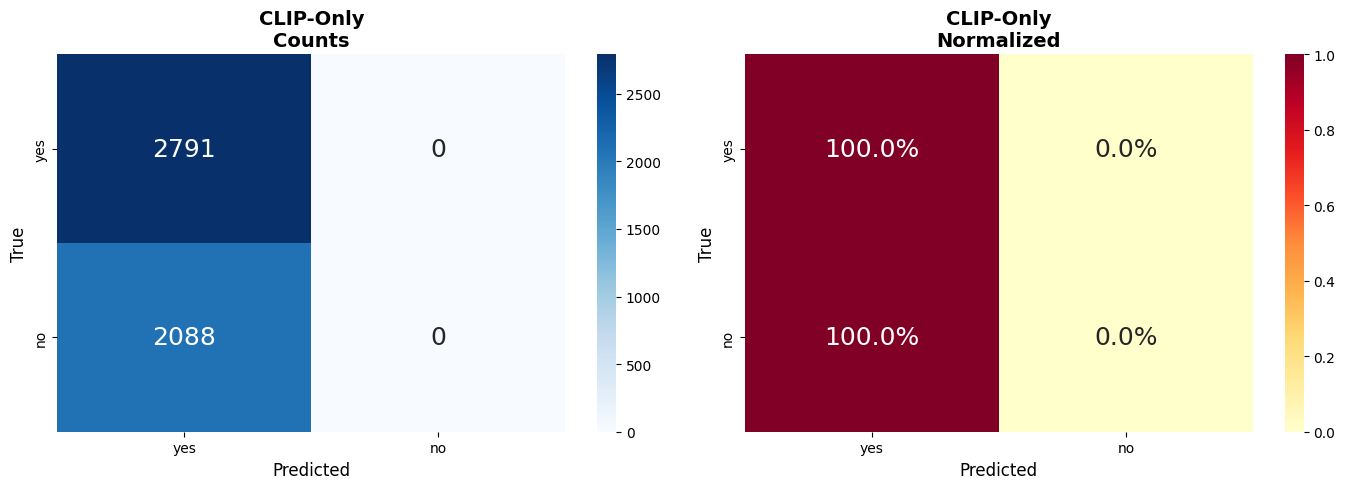


--- Ensemble (CNN + CLIP) Model ---
  Saved: /content/drive/MyDrive/VQA_capstone_1/analysis_results/confusion_matrix_ensemble.png


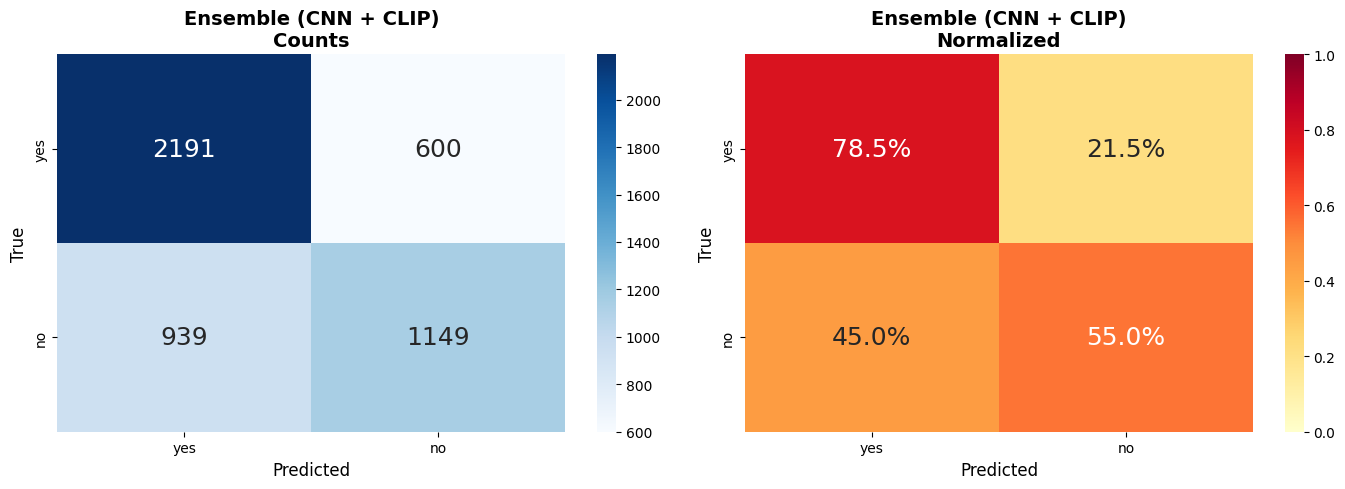

In [ ]:

def plot_2x2_confusion_matrix(y_true_texts, y_pred_texts, model_name, save_path=None):
    """Plot a simple 2×2 confusion matrix for yes/no predictions."""
    labels = ['yes', 'no']
    cm = confusion_matrix(y_true_texts, y_pred_texts, labels=labels)

    cm_norm = cm.astype(np.float64)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm_norm / row_sums

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[0], annot_kws={'size': 18})
    axes[0].set_title(f'{model_name}\nCounts', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('True', fontsize=12)

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels,
                ax=axes[1], vmin=0, vmax=1, annot_kws={'size': 18})
    axes[1].set_title(f'{model_name}\nNormalized', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted', fontsize=12)
    axes[1].set_ylabel('True', fontsize=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    plt.show()


print("=" * 70)
print("2×2 CONFUSION MATRICES (Yes / No)")
print("=" * 70)

print("\n--- CNN-Only Model ---")
plot_2x2_confusion_matrix(
    cnn_results['all_label_texts'], cnn_results['all_pred_texts'],
    "CNN-Only (ResNet50)",
    save_path=os.path.join(RESULTS_DIR, "confusion_matrix_cnn_only.png")
)

print("\n--- CLIP-Only Model ---")
plot_2x2_confusion_matrix(
    clip_results['all_label_texts'], clip_results['all_pred_texts'],
    "CLIP-Only",
    save_path=os.path.join(RESULTS_DIR, "confusion_matrix_clip_only.png")
)

print("\n--- Ensemble (CNN + CLIP) Model ---")
plot_2x2_confusion_matrix(
    ensemble_results['all_label_texts'], ensemble_results['all_pred_texts'],
    "Ensemble (CNN + CLIP)",
    save_path=os.path.join(RESULTS_DIR, "confusion_matrix_ensemble.png")
)


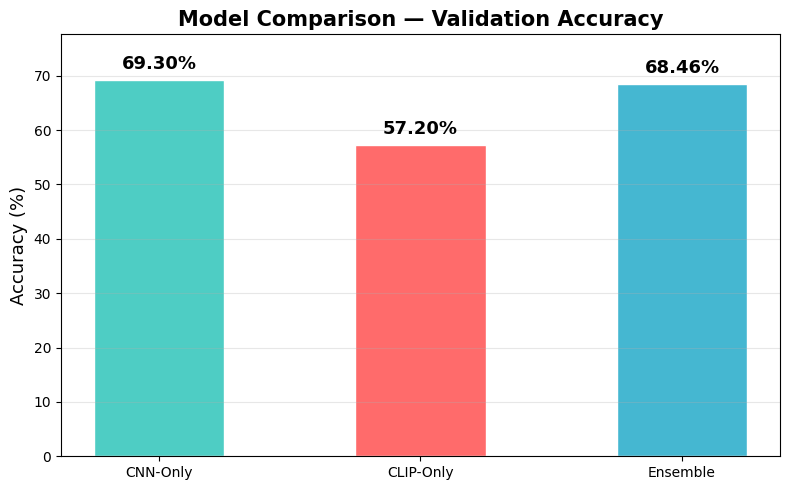

Saved accuracy comparison chart.


In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))

model_names = ['CNN-Only', 'CLIP-Only', 'Ensemble']
accuracies = [
    cnn_results['accuracy'] * 100,
    clip_results['accuracy'] * 100,
    ensemble_results['accuracy'] * 100
]
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']

bars = ax.bar(model_names, accuracies, color=colors, edgecolor='white', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.annotate(f'{acc:.2f}%', xy=(bar.get_x() + bar.get_width()/2, acc),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Model Comparison — Validation Accuracy', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(accuracies) * 1.12)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "accuracy_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved accuracy comparison chart.")


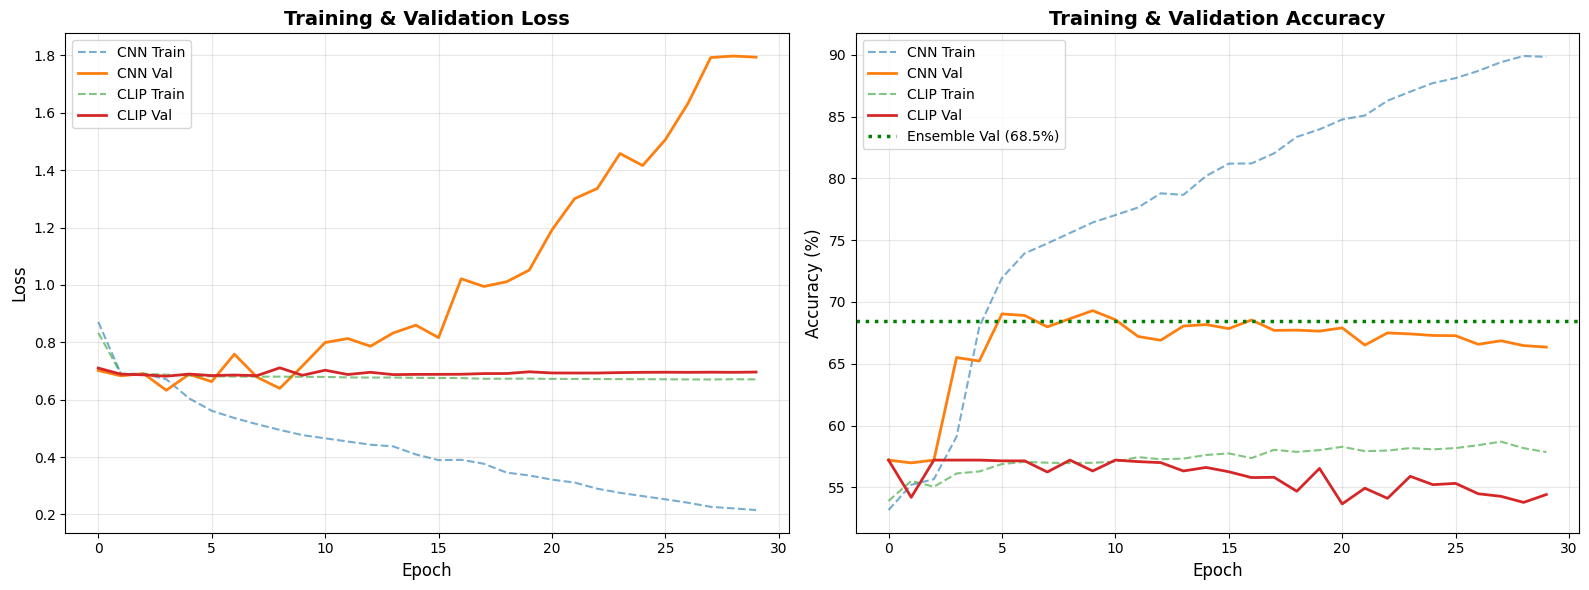

Saved training curves comparison.


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(cnn_history['train_loss'], '--', label='CNN Train', alpha=0.6, linewidth=1.5)
axes[0].plot(cnn_history['val_loss'], '-', label='CNN Val', linewidth=2)
axes[0].plot(clip_history['train_loss'], '--', label='CLIP Train', alpha=0.6, linewidth=1.5)
axes[0].plot(clip_history['val_loss'], '-', label='CLIP Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in cnn_history['train_acc']], '--', label='CNN Train', alpha=0.6, linewidth=1.5)
axes[1].plot([a*100 for a in cnn_history['val_acc']], '-', label='CNN Val', linewidth=2)
axes[1].plot([a*100 for a in clip_history['train_acc']], '--', label='CLIP Train', alpha=0.6, linewidth=1.5)
axes[1].plot([a*100 for a in clip_history['val_acc']], '-', label='CLIP Val', linewidth=2)
axes[1].axhline(y=ensemble_results['accuracy']*100, color='green', linestyle=':',
                linewidth=2.5, label=f"Ensemble Val ({ensemble_results['accuracy']*100:.1f}%)")
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved training curves comparison.")


In [ ]:

labels = ['yes', 'no']

for name, results in [("CNN-Only", cnn_results), ("CLIP-Only", clip_results), ("Ensemble", ensemble_results)]:
    print(f"\n{'=' * 70}")
    print(f"CLASSIFICATION REPORT — {name}")
    print(f"{'=' * 70}")
    print(classification_report(
        results['all_label_texts'], results['all_pred_texts'],
        labels=labels, target_names=labels, zero_division=0
    ))



CLASSIFICATION REPORT — CNN-Only
              precision    recall  f1-score   support

         yes       0.69      0.85      0.76      2791
          no       0.70      0.49      0.58      2088

    accuracy                           0.69      4879
   macro avg       0.70      0.67      0.67      4879
weighted avg       0.70      0.69      0.68      4879


CLASSIFICATION REPORT — CLIP-Only
              precision    recall  f1-score   support

         yes       0.57      1.00      0.73      2791
          no       0.00      0.00      0.00      2088

    accuracy                           0.57      4879
   macro avg       0.29      0.50      0.36      4879
weighted avg       0.33      0.57      0.42      4879


CLASSIFICATION REPORT — Ensemble
              precision    recall  f1-score   support

         yes       0.70      0.79      0.74      2791
          no       0.66      0.55      0.60      2088

    accuracy                           0.68      4879
   macro avg       0.68  

In [ ]:

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

models_ranked = sorted([
    ("CNN-Only (ResNet50)", cnn_results['accuracy']),
    ("CLIP-Only", clip_results['accuracy']),
    ("Ensemble (CNN+CLIP)", ensemble_results['accuracy']),
], key=lambda x: x[1], reverse=True)

print("\n  Overall Ranking:")
for rank, (name, acc) in enumerate(models_ranked, 1):
    medal = ["1st", "2nd", "3rd"][rank-1]
    print(f"    {medal} {rank}. {name:<25} {acc*100:.2f}%")

ens_overall = ensemble_results['accuracy'] * 100
cnn_overall = cnn_results['accuracy'] * 100
clip_overall = clip_results['accuracy'] * 100
best_single = max(cnn_overall, clip_overall)
advantage = ens_overall - best_single

print(f"\n  Ensemble advantage over best single model: {advantage:+.2f}%")
if advantage > 0:
    print("The ensemble IS better than individual models.")
else:
    print("The ensemble did NOT outperform the best individual model.")
    print("This may indicate one feature type dominates for this dataset.")
print("=" * 70)



FINAL SUMMARY

  Overall Ranking:
    1st 1. CNN-Only (ResNet50)       69.30%
    2nd 2. Ensemble (CNN+CLIP)       68.46%
    3rd 3. CLIP-Only                 57.20%

  Ensemble advantage over best single model: -0.84%
The ensemble did NOT outperform the best individual model.
This may indicate one feature type dominates for this dataset.
